# Diseño e Implementación de Pipeline Analítico Secuencial (Reto)
Iván Alejandro López Valenzuela - A01284875

Roberto Priego Bautista - A01285539

Joaquin Sainz Muleiro - A01783801

Eduardo Mitrani Krouham - A01783220

Marcos Aquino Garcia - A00835576	
	
Sergio Alejandro Esparza González - A01625430

## EDA, Limpieza y Análisis Competitivo de Modelos: HIS-10 (Optimizador de Agendas)

### 1. Definición del Caso de Uso
Los hospitales y el sistema de salud enfrentan un reto crítico en la alta tasa de ausentismo a citas (No-Show) que oscila entre el 15% y 25%. Esto genera consultorios vacíos, pérdida neta de ingresos y un uso ineficiente del personal médico y administrativo provocado en gran medida por la falta de visibilidad en tiempo real. Por lo tanto, se plantea como objetivo principal el desarrollar y desplegar una solución para este caso de uso que reduzca el ausentismo a citas médicas mediante clasificación binaria de riesgo. 

Esta incluirá en primer lugar un modelo capaz de predecir con precisión y con antelación la inasistencia, permitiendo establecer una estrategia de sobreagendamiento inteligente donde, basado en la probabilidad de inasistencia, se optimice el slot sin saturar al médico. También se busca incluir una conexión técnica con el inventario de datos proporcionados por los hospitales y capacidad de operar en múltiples sedes hospitalarias, además de tener un impacto en métricas referentes al uso efectivo de consultorios, ausentismo a citas médicas y satisfacción de los pacientes.

A continuación y para fines de esta entrega, se realiza un análisis exploratorio y procesamiento de los datos proporcionados para alinear de una mejor manera la definición de los objetivos con la realidad de los datos que se tienen disponibles, así como para contar con el primer paso del pipeline que se conectará con las arquitecturas de modelos que se pondrán a competir más adelante. 

#### Análisis exploratorio y de calidad de datos + Procesamiento
El objetivo es revisar la calidad de los datos, validar integraciones entre tablas y justificar las decisiones de limpieza que para el reto serán implementadas en un pipeline de Data Engineering con Kedro.

##### Configuración inicial

In [1]:
#Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable
import unicodedata
import seaborn as sns
#Configuración de visualización en pandas
# Se amplía el número de columnas y filas visibles para facilitar la inspección de tablas durante el análisis exploratorio.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

##### Carga de datos crudos
Se cargan las 3 tablas crudas principales que se usarán para construir los datasets del caso de uso.

En esta etapa todavía no se aplican transformaciones; únicamente se leen los archivos originales desde la carpeta `data/01_raw` para revisar su estructura inicial, número de registros, columnas disponibles y posibles problemas de calidad.

Tablas consideradas:

- `HOSMPI`: contiene datos generales de los pacientes.

- `HOSPAC`: contiene los episodios de atención hospitalaria de los pacientes, es decir, registros de ingresos, estancias o atenciones asociadas a cada paciente.

- `HOSAGD`: contiene la agenda de citas médicas programadas.

In [2]:
# Carga de tablas crudas
# Se leen los archivos .parquet desde la capa raw del proyecto.
# Estas tablas corresponden a las fuentes principales usadas para el caso HIS-10.

raw_tables = {
    "hosmpi": pd.read_parquet("../data/01_raw/hosmpi.parquet"),
    "hospac": pd.read_parquet("../data/01_raw/hospac.parquet"),
    "hosagd": pd.read_parquet("../data/01_raw/hosagd.parquet"),
}

# Resumen de dimensiones
# Se construye una tabla resumen con el número de filas y columnas de cada fuente.
# Esto permite conocer el tamaño inicial de cada tabla antes de aplicar limpieza, transformaciones o integraciones.

summary = pd.DataFrame({
    "table": list(raw_tables.keys()),
    "rows": [df.shape[0] for df in raw_tables.values()],
    "columns": [df.shape[1] for df in raw_tables.values()],
})

# Se muestra el resumen para documentar la estructura inicial de las tablas crudas.
summary

,table,rows,columns
0,hosmpi,37460,24
1,hospac,115593,106
2,hosagd,73018,15


El resumen muestra las dimensiones iniciales de las tablas crudas cargadas desde `data/01_raw`.

La tabla con mayor número de registros es `HOSPAC`, con 115,593 filas y 106 columnas, lo que indica que contiene una cantidad amplia de información asociada a episodios de atención hospitalaria. Le sigue `HOSAGD`, con 73,018 registros, que será la fuente principal para el caso HIS-10 por contener la agenda de citas médicas.

Este conteo inicial sirve como referencia para comparar los cambios que ocurran después de la limpieza, filtrado e integración de las tablas.

##### Vista preliminar de las tablas crudas

In [3]:
# Se muestran las primeras filas de cada tabla para revisar su estructura inicial:
# nombres de columnas, formato de los valores, presencia visible de nulos y posibles llaves de integración.

for table_name, df in raw_tables.items():
    print(f"\n===== {table_name.upper()} =====")
    display(df.head(3))

# Columnas disponibles por tabla

# Se listan las columnas de cada fuente para identificar variables relevantes y posibles llaves de unión entre tablas.

for table_name, df in raw_tables.items():
    print(f"\n===== {table_name.upper()} =====")
    print(df.columns.tolist())


===== HOSMPI =====


,ibuff,m_status,m_num_exp,m_ficha_tra,m_sexo,m_civil,m_fec_nac,m_lug_nac,m_ciu,m_col,m_del,m_cp,m_edo,m_pai,m_fax,m_cod_cia,m_hos_ori,m_rec_usr,m_ult_cam_usr,m_ult_cam_fec,m_ult_cam_hra,m_fec_ven_der,m_edad,m_buffer
0,,10,00000000000000000001,,F,U,19760328,,,,,,,,,,,SCP,SCP,20250728,150254,20440514,49A,
1,,10,00000000000000000002,,F,S,20130406,,,,,,,,,,,SCP,SCP,20250728,150835,20440515,12A,
2,,50,00000000000000000003,,F,,19850425,,,,,,,,,,,CTO,CTO,20240515,073557,20440515,40A,



===== HOSPAC =====


,ibuff,p_num_exp,p_area,p_area_ori,p_status,p_res_cve_num,p_res_cve_mbo,p_res_fec,p_res_hra,p_res_hab,p_tpo_paq,p_cod_cia,p_tpo_tfa,p_tfa,p_tpo_mon,p_sexo,p_fec_lld,p_hra_lld,p_fec_reg,p_hra_reg,p_fec_sda,p_hra_sda,FechaAltaMedica,HoraAltaMedica,UsrAltaMedica,FechaAltaAdministrativa,HoraAltaAdministrativa,UsrAltaAdministrativa,FechaFacturacion,p_tpo_cto,p_num_cto,CuartoEntrada,CuartoSalida,p_fol_cto,p_fol_ext,p_tpo_pac,p_tpo_cita,p_seg_mer,PaisNacimiento,EstadoNacimiento,LugarHospedaje,HabitacionHospedaje,FechaPartida,ComoSeEntero,p_res_usr,p_ult_cam_usr,p_ult_cam_fec,p_ult_cam_hra,p_usr_adm,p_con_for_pgo,...,p_cas,p_dpto,p_esp,p_diag,MotivoSalida,p_diagsalida,Tratamiento,Cirugia1,Cirugia2,Cirugia3,PasaHospitalizacion,AccidenteLaboral,AreaMadre,CveIngresoMadre,Sexo,Peso,Nacido,Parto,AlSalir,PacienteColonia,PacienteCiudad,PacienteDelegacion,PacienteEstado,PacientePais,PacienteOcupacion,EmpPacienteCiudad,EmpPacienteDelegacion,EmpPacienteEstado,EmpPacientePais,EmpPacienteOcupacion,ResponsableCiudad,ResponsableDelegacion,ResponsableEstado,ResponsablePais,ResponsableOcupacion,ParentescoResponsable,EmpResponsableCiudad,EmpResponsableDelegacion,EmpResponsableEstado,EmpResponsablePais,EmpResponsableOcupacion,ContactoDelegacion,ContactoEstado,ContactoPais,ContactoOcupacion,ParentescoContacto,TipoPoliza,Siniestro,ValeConsumo,InternoExterno
0,,CEX00000000000001364,CUN,,02,1,1,20240515,090957,,,,,0.0,,F,20240521,093000,,,,102900,,,,,,,,,,,,,,,P,,,,,,,,MML,MML,20240521,132711,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,,00000000000000000785,CUN,,00,2,1,20240515,104532,,,,,0.0,,M,20240521,163000,20240521,162526,,172900,,,,,,,,,,,,,,LOC,P,2.1,,,,,,,MML,MML,20240521,162556,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,,CEX00000000000002483,CUN,,00,3,1,20240522,152003,,,,,0.0,,M,20240522,160000,,,,165900,,,,,,,,,,,,,,,P,,,,,,,,MML,MML,20240522,152003,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,



===== HOSAGD =====


,med,esp,a_fecha,area,cve_num,cve_mbo,dur,hra_ini,hra_fin,tpo_cita,conflicto,asistencia,agregada,ultimahora,buffer
0,000002,ODONTO,20240925,CZM,10895,1,30,0900,0929,P,,,,,N
1,000002,ODONTO,20240925,CZM,10896,1,30,0930,0959,P,,,,,N
2,000002,ODONTO,20240925,CZM,10906,1,30,1000,1029,P,,,,,N



===== HOSMPI =====
['ibuff', 'm_status', 'm_num_exp', 'm_ficha_tra', 'm_sexo', 'm_civil', 'm_fec_nac', 'm_lug_nac', 'm_ciu', 'm_col', 'm_del', 'm_cp', 'm_edo', 'm_pai', 'm_fax', 'm_cod_cia', 'm_hos_ori', 'm_rec_usr', 'm_ult_cam_usr', 'm_ult_cam_fec', 'm_ult_cam_hra', 'm_fec_ven_der', 'm_edad', 'm_buffer']

===== HOSPAC =====
['ibuff', 'p_num_exp', 'p_area', 'p_area_ori', 'p_status', 'p_res_cve_num', 'p_res_cve_mbo', 'p_res_fec', 'p_res_hra', 'p_res_hab', 'p_tpo_paq', 'p_cod_cia', 'p_tpo_tfa', 'p_tfa', 'p_tpo_mon', 'p_sexo', 'p_fec_lld', 'p_hra_lld', 'p_fec_reg', 'p_hra_reg', 'p_fec_sda', 'p_hra_sda', 'FechaAltaMedica', 'HoraAltaMedica', 'UsrAltaMedica', 'FechaAltaAdministrativa', 'HoraAltaAdministrativa', 'UsrAltaAdministrativa', 'FechaFacturacion', 'p_tpo_cto', 'p_num_cto', 'CuartoEntrada', 'CuartoSalida', 'p_fol_cto', 'p_fol_ext', 'p_tpo_pac', 'p_tpo_cita', 'p_seg_mer', 'PaisNacimiento', 'EstadoNacimiento', 'LugarHospedaje', 'HabitacionHospedaje', 'FechaPartida', 'ComoSeEntero', 'p_

La vista preliminar de las tablas crudas permite identificar la estructura general de cada fuente antes de aplicar cualquier proceso de limpieza.

Para la interpretación del significado específico de cada variable, se utiliza como apoyo el diccionario de datos compartido por TCA. Sin embargo, esta inspección inicial permite confirmar que las columnas cargadas corresponden a las tablas esperadas.

En `HOSMPI` aparecen variables demográficas del paciente, como número de expediente, sexo, estado civil, fecha de nacimiento, edad y datos de ubicación. Por ello, esta tabla se usa como apoyo para enriquecer los registros con información del paciente.

En `HOSPAC` se observa una tabla amplia, con muchas columnas administrativas y clínicas asociadas a episodios de atención, incluyendo identificadores de paciente, área, fechas, horas, sexo, tipo de paciente, diagnóstico y datos relacionados con la salida o facturación.

En `HOSAGD` se identifican variables propias de una agenda de citas, como médico, especialidad, fecha, área, clave de reservación, duración, hora de inicio, hora de fin y asistencia. Esto confirma que esta tabla es la fuente principal para el caso HIS-10.

También se observa que varias columnas contienen valores vacíos o formatos que requieren limpieza, por ejemplo fechas y horas representadas como números o texto, edades con formato alfanumérico como `30A`, y campos categóricos codificados. Estos aspectos se revisan en las siguientes secciones.

##### Calidad inicial: tipos, nulos y duplicados
Se revisa el estado inicial de las tablas crudas antes de aplicar las limpiezas formales del pipeline.

El objetivo es identificar problemas básicos de calidad de datos, como tipos de variables incorrectos, valores faltantes, columnas completamente vacías, registros duplicados y posibles inconsistencias visibles en las fuentes originales.

Esta revisión funciona como diagnóstico inicial para justificar las transformaciones que se aplican posteriormente en el proceso de Data Engineering.

In [4]:
# Función auxiliar para resumir valores faltantes
# Esta función calcula, para cada columna de una tabla:
# - número de valores faltantes,
# - porcentaje de valores faltantes,
# - tipo de dato detectado por pandas.
# El resultado se ordena de mayor a menor porcentaje de faltantes.

def missing_summary(df):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes],
    })
    return out.sort_values("missing_pct", ascending=False)

# Diagnóstico inicial de calidad por tabla cruda
# Para cada fuente se reportan:
# - dimensiones de la tabla,
# - número de filas completamente duplicadas,
# - las 15 columnas con mayor porcentaje de valores faltantes.
# Esta revisión permite identificar problemas de calidad antes de aplicar las limpiezas formales del pipeline.

for name, df in raw_tables.items():
    print("=" * 80)
    print(name.upper())
    print("shape:", df.shape)
    print("duplicated full rows:", df.duplicated().sum())
    display(missing_summary(df).head(15))

HOSMPI
shape: (37460, 24)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,ibuff,0,0.0,object
1,m_status,0,0.0,object
2,m_num_exp,0,0.0,object
3,m_ficha_tra,0,0.0,object
4,m_sexo,0,0.0,object
5,m_civil,0,0.0,object
6,m_fec_nac,0,0.0,object
7,m_lug_nac,0,0.0,object
8,m_ciu,0,0.0,object
9,m_col,0,0.0,object


HOSPAC
shape: (115593, 106)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
105,InternoExterno,3168,2.74,object
0,ibuff,0,0.00,object
2,p_area,0,0.00,object
3,p_area_ori,0,0.00,object
4,p_status,0,0.00,object
5,p_res_cve_num,0,0.00,object
6,p_res_cve_mbo,0,0.00,object
7,p_res_fec,0,0.00,object
8,p_res_hra,0,0.00,object
1,p_num_exp,0,0.00,object


HOSAGD
shape: (73018, 15)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,med,0,0.0,object
1,esp,0,0.0,object
2,a_fecha,0,0.0,object
3,area,0,0.0,object
4,cve_num,0,0.0,object
5,cve_mbo,0,0.0,object
6,dur,0,0.0,int64
7,hra_ini,0,0.0,object
8,hra_fin,0,0.0,object
9,tpo_cita,0,0.0,object


El diagnóstico inicial muestra que ninguna de las tablas presenta filas completamente duplicadas. Esto indica que, al menos a nivel de fila completa, no existen registros repetidos idénticos en las fuentes crudas.

Sin embargo, en el análisis de valores faltantes varias tablas muestran pocos o ningún faltante detectado mediante `isna()`, pero en la vista preliminar se observaron campos vacíos representados como cadenas en blanco o espacios. Por ello, el conteo de nulos mostrado aquí refleja únicamente valores reconocidos por pandas como `NaN` o `None`, no todos los vacíos semánticos presentes en los datos.

En `HOSPAC`, la única columna con faltantes detectados en este resumen es `InternoExterno`, con 2.74% de valores faltantes. No obstante, por la cantidad de columnas tipo `object`, es necesario revisar posteriormente valores vacíos codificados como texto.

En `HOSAGD`, no se detectan faltantes con `isna()`, pero variables como `asistencia`, `conflicto`, `agregada` o `ultimahora` pueden contener valores en blanco que requieren limpieza. Esta tabla es especialmente importante porque `asistencia` será clave para construir la variable objetivo del caso HIS-10.

En `HOSMPI`, tampoco se detectan faltantes con `isna()`, aunque algunas columnas demográficas pueden contener espacios o cadenas vacías. Además, variables como fecha de nacimiento y edad aparecen inicialmente como tipo `object`, por lo que requieren transformación posterior.

In [5]:
# Función auxiliar para contar faltantes extendidos
# La función reemplaza temporalmente cadenas vacías o espacios por NaN.
# Después calcula, para cada columna:
# - cantidad de valores faltantes,
# - porcentaje de valores faltantes,
# - tipo de dato original.
# Esto permite obtener un diagnóstico más realista de la ausencia de información.

def missing_summary_extended(df):
    df_clean = df.replace(r"^\s*$", np.nan, regex=True)
    
    out = pd.DataFrame({
        "column": df_clean.columns,
        "missing_count": df_clean.isna().sum().values,
        "missing_pct": (df_clean.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes],
    })
    
    return out.sort_values("missing_pct", ascending=False)

# Aplicación del diagnóstico extendido a cada tabla cruda
# Se aplica la función a todas las tablas cargadas para identificar las columnas con mayor proporción de valores faltantes reales o semánticos.
# Solo se muestran las 15 columnas con mayor porcentaje de faltantes por tabla.

for name, df in raw_tables.items():
    print("=" * 80)
    print(name.upper())
    display(missing_summary_extended(df).head(15))

HOSMPI


C:\Users\ivanl\AppData\Local\Temp\ipykernel_17524\3623647745.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df.replace(r"^\s*$", np.nan, regex=True)


,column,missing_count,missing_pct,dtype
0,ibuff,37460,100.00,object
3,m_ficha_tra,37460,100.00,object
14,m_fax,37460,100.00,object
10,m_del,37460,100.00,object
16,m_hos_ori,37460,100.00,object
23,m_buffer,37460,100.00,object
7,m_lug_nac,37450,99.97,object
9,m_col,34108,91.05,object
11,m_cp,33570,89.62,object
15,m_cod_cia,31333,83.64,object


HOSPAC


C:\Users\ivanl\AppData\Local\Temp\ipykernel_17524\3623647745.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df.replace(r"^\s*$", np.nan, regex=True)


,column,missing_count,missing_pct,dtype
9,p_res_hab,115593,100.0,object
3,p_area_ori,115593,100.0,object
41,HabitacionHospedaje,115593,100.0,object
39,EstadoNacimiento,115593,100.0,object
28,FechaFacturacion,115593,100.0,object
31,CuartoEntrada,115592,100.0,object
32,CuartoSalida,115592,100.0,object
40,LugarHospedaje,115593,100.0,object
100,ContactoOcupacion,115593,100.0,object
96,EmpResponsableOcupacion,115593,100.0,object


HOSAGD


,column,missing_count,missing_pct,dtype
13,ultimahora,72970,99.93,object
12,agregada,72970,99.93,object
10,conflicto,72181,98.85,object
11,asistencia,44463,60.89,object
8,hra_fin,70,0.10,object
14,buffer,50,0.07,object
0,med,0,0.00,object
6,dur,0,0.00,int64
5,cve_mbo,0,0.00,object
4,cve_num,0,0.00,object


El diagnóstico extendido muestra una diferencia importante respecto al conteo inicial de nulos. Al considerar también cadenas vacías y espacios como valores faltantes, se observa que varias columnas sí tienen una proporción alta de información ausente.

En `HOSMPI`, muchas columnas demográficas o administrativas aparecen completamente vacías o con porcentajes muy altos de faltantes, como `ibuff`, `m_ficha_tra`, `m_fax`, `m_del`, `m_hos_ori` y `m_buffer`. También se observan altos porcentajes de faltantes en variables de ubicación como ciudad, estado, país y código postal. Por lo tanto, para enriquecer los datos del paciente conviene priorizar variables más completas, como expediente, sexo, fecha de nacimiento o edad, y evitar columnas con ausencia casi total.

En `HOSPAC`, varias columnas relacionadas con hospedaje, facturación, ubicación o datos de responsables/contactos presentan 100% de faltantes. Esto indica que no todas las variables disponibles en la tabla son útiles para el análisis. Para los casos de uso seleccionados, se deben conservar principalmente las variables asociadas al episodio de atención, identificadores, fechas, horas, área, sexo, tipo de paciente, especialidad y diagnóstico.

En `HOSAGD`, la tabla de agenda médica presenta columnas casi completamente vacías como `ultimahora`, `agregada` y `conflicto`, por lo que no parecen aportar información suficiente para el modelado. La variable `asistencia`, relevante para HIS-10, tiene 60.89% de faltantes al considerar espacios como valores vacíos. Esto implica que no todos los registros de citas pueden usarse directamente para construir la variable objetivo de No-Show; se deben conservar únicamente los registros con valores válidos de asistencia.

En conjunto, este análisis confirma que en las fuentes crudas existen muchos vacíos codificados como cadenas en blanco. Esta revisión justifica la estandarización de faltantes y la selección de variables más completas en las etapas posteriores del pipeline.

##### Implementación de transformaciones
Se aplican las funciones de limpieza que forman parte del pipeline de Data Engineering.

A diferencia de las secciones anteriores, donde solo se diagnosticaba la calidad inicial de las tablas crudas, en esta etapa sí se ejecutan transformaciones formales sobre los datos. Estas limpiezas permiten estandarizar formatos, corregir tipos de datos, homologar valores vacíos y preparar las tablas para su integración posterior.

In [6]:
def _strip_string_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip leading/trailing spaces from text columns, remove control characters,
    and convert empty strings to NA.
    """

    df = df.copy()

    # Raw Assist tables contain padded strings, blank values and sometimes
    # non-printable/control characters. This standardizes text fields before
    # joins, filtering, and feature creation.
    for col in df.columns:
        if df[col].dtype == "object" or str(df[col].dtype).startswith("string"):
            df[col] = (
                df[col]
                .astype("string")
                .str.replace(r"[\x00-\x1F\x7F]", "", regex=True)
                .str.strip()
                .replace("", pd.NA)
            )

    return df


def _normalize_code_columns(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """
    Normalize categorical code-like columns.

    This is used for administrative codes and compact categorical fields where
    differences in spaces or letter case should not create different categories.
    """

    df = df.copy()

    for col in columns:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype("string")
                .str.replace(r"[\x00-\x1F\x7F]", "", regex=True)
                .str.strip()
                .str.upper()
                .replace("", pd.NA)
            )

    return df


def _replace_noninformative_codes(
    df: pd.DataFrame,
    replacements: dict[str, set[str]],
) -> pd.DataFrame:
    """
    Replace non-informative categorical codes with NA.

    These values are not treated as valid categories. Later, in the modeling base,
    categorical missing values can be represented as UNKNOWN.
    """

    df = df.copy()

    for col, invalid_values in replacements.items():
        if col in df.columns:
            s = df[col].astype("string").str.strip().str.upper()
            df[col] = s.mask(s.isin(invalid_values), pd.NA)

    return df


def _standardize_time_hhmmss(series: pd.Series) -> pd.Series:
    """
    Standardize time strings to HHMMSS.

    Examples:
    - '0900'   -> '090000'
    - '93000'  -> '093000'
    - '093000' -> '093000'
    """

    # Raw time columns are not always consistent.
    # Some values come as HHMM, others as HHMMSS, and some may lose leading zeros.
    s = series.astype("string").str.strip().replace("", pd.NA)
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)

    def fix_time(value):
        """
        Normalize one raw time value into a six-character HHMMSS string.
        """
        if pd.isna(value):
            return pd.NA

        value = str(value)

        if len(value) == 6:
            return value
        if len(value) == 5:
            return "0" + value
        if len(value) == 4:
            return value + "00"
        if len(value) == 3:
            return "0" + value + "00"
        if len(value) == 2:
            return value + "0000"
        if len(value) == 1:
            return "0" + value + "0000"

        return value.zfill(6)[-6:]

    return s.map(fix_time).astype("string")


def _parse_datetime_from_date_time(
    df: pd.DataFrame,
    date_col: str,
    time_col: str,
) -> pd.Series:
    """
    Parse datetime from date column YYYYMMDD and time column HHMMSS/HHMM.

    Invalid values become NaT.
    """

    # If a table does not contain the expected date/time columns,
    # return NaT instead of breaking the pipeline.
    if date_col not in df.columns or time_col not in df.columns:
        return pd.Series(pd.NaT, index=df.index)

    date_s = df[date_col].astype("string").str.strip().replace("", pd.NA)
    date_s = date_s.str.replace(r"\.0$", "", regex=True)
    date_s = date_s.str.replace(r"\D", "", regex=True)

    time_s = _standardize_time_hhmmss(df[time_col])

    raw = date_s + time_s

    return pd.to_datetime(raw, format="%Y%m%d%H%M%S", errors="coerce")


def _safe_numeric(series: pd.Series) -> pd.Series:
    """
    Convert a column to numeric values.

    Invalid values are converted to NaN instead of breaking the pipeline.
    Numeric missing values are not imputed here because imputation should be
    decided later by the Data Science/modeling step.
    """

    return pd.to_numeric(series.astype("string").str.strip(), errors="coerce")


def _add_temporal_features(
    df: pd.DataFrame,
    datetime_col: str,
    prefix: str = "",
) -> pd.DataFrame:
    """
    Add calendar-based features from a datetime column.

    Created features:
    - hour
    - day_of_week
    - day
    - month
    - is_weekend

    These features help models capture hourly, daily, and weekly patterns.
    """

    df = df.copy()

    col_prefix = f"{prefix}_" if prefix else ""

    df[f"{col_prefix}hour"] = df[datetime_col].dt.hour
    df[f"{col_prefix}day_of_week"] = df[datetime_col].dt.dayofweek
    df[f"{col_prefix}day"] = df[datetime_col].dt.day
    df[f"{col_prefix}month"] = df[datetime_col].dt.month
    df[f"{col_prefix}is_weekend"] = (
        df[f"{col_prefix}day_of_week"].isin([5, 6]).astype(int)
    )

    return df


def _fill_categorical_missing(
    df: pd.DataFrame,
    columns: Iterable[str],
) -> pd.DataFrame:
    """
    Fill missing categorical columns with 'UNKNOWN'.
    """

    df = df.copy()

    # For categorical variables, missing values are kept as an explicit category.
    # This is useful for tree-based models such as CatBoost.
    # Numeric imputation is intentionally not done here; that belongs to modeling decisions.
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("UNKNOWN")

    return df

In [7]:
def clean_hospac(hospac: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia tabla HOSPAC patient/encounter.
    La tabla se usa como conexión entre las citas y la información del paciente.
    """

    df = _strip_string_columns(hospac)

    df = _normalize_code_columns(
        df,
        [
            "p_area",
            "p_status",
            "p_sexo",
            "p_tpo_pac",
            "p_tpo_cita",
            "p_res_cve_num",
            "p_res_cve_mbo",
        ],
    )

    #Crea claves de unión normalizadas.
    # Estas claves se utilizan posteriormente para conectar HOSPAC con HOSAGD sin duplicar citas.
    df["area_key"] = df["p_area"].astype("string").str.strip()
    df["cve_num_key"] = df["p_res_cve_num"].astype("string").str.strip()
    df["cve_mbo_key"] = df["p_res_cve_mbo"].astype("string").str.strip()
    df["p_num_exp_key"] = df["p_num_exp"].astype("string").str.strip()

    # Parsea los campos de fecha/hora y los covierte en columnas de fecha y hora reales.
    # Esto es útil para las funciones de plazos y el análisis de tiempos operativos.
    df["reservation_datetime"] = _parse_datetime_from_date_time(
        df,
        "p_res_fec",
        "p_res_hra",
    )
    df["arrival_datetime"] = _parse_datetime_from_date_time(
        df,
        "p_fec_lld",
        "p_hra_lld",
    )
    df["registration_datetime"] = _parse_datetime_from_date_time(
        df,
        "p_fec_reg",
        "p_hra_reg",
    )

    # Conserva solo las columnas necesarias para uniones, creación de entidades o modelado posterior.
    # Esto reduce el ruido de las tablas operativas sin procesar con muchos campos sin usar.
    useful_cols = [
        "area_key",
        "cve_num_key",
        "cve_mbo_key",
        "p_num_exp_key",
        "p_area",
        "p_status",
        "p_sexo",
        "p_tpo_pac",
        "p_tpo_cita",
        "reservation_datetime",
        "arrival_datetime",
        "registration_datetime",
    ]

    useful_cols = [col for col in useful_cols if col in df.columns]

    return df[useful_cols].drop_duplicates()


def clean_hosagd(hosagd: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia la tabla de programación de citas de HOSAGD.

    Esta es la tabla principal para HIS-10 No-Show Guard, ya que contiene:
    información de programación de citas y el campo de asistencia sin procesar utilizado para
    construir el objetivo no_show.
    """

    df = _strip_string_columns(hosagd)

    df = _normalize_code_columns(
        df,
        [
            "area",
            "cve_num",
            "cve_mbo",
            "med",
            "esp",
            "tpo_cita",
            "conflicto",
            "agregada",
            "ultimahora",
            "buffer",
            "asistencia",
        ],
    )

    df["area_key"] = df["area"].astype("string").str.strip()
    df["cve_num_key"] = df["cve_num"].astype("string").str.strip()
    df["cve_mbo_key"] = df["cve_mbo"].astype("string").str.strip()

    # Implementa la timestamp y las características temporales de la cita.

    # Estas características están disponibles antes de la cita y son seguras para la predicción de inasistencias.
    df["appointment_datetime"] = _parse_datetime_from_date_time(df, "a_fecha", "hra_ini")
    df = _add_temporal_features(df, "appointment_datetime", prefix="appointment")

    df["duration_min"] = _safe_numeric(df["dur"])

    # La duración de las citas debe ser positiva para que sea informativa.
    # Las duraciones no válidas se dejan como NaN para la etapa de modelado.
    df.loc[df["duration_min"] <= 0, "duration_min"] = np.nan

    # Construcción del objetivo HIS-10:
    # A = cita asistida.
    # I = cita perdida/no se presentó.
    # Los valores de asistencia faltantes o inválidos NO se imputan porque se desconoce el resultado real.
    df["asistencia_clean"] = (
        df["asistencia"]
        .astype("string")
        .str.replace(r"[\x00-\x1F\x7F]", "", regex=True)
        .str.strip()
        .str.upper()
        .replace("", pd.NA)
    )

    df["asistencia_invalid"] = (
        df["asistencia_clean"].notna()
        & ~df["asistencia_clean"].isin(["A", "I"])
    ).astype(int)

    df.loc[~df["asistencia_clean"].isin(["A", "I"]), "asistencia_clean"] = pd.NA

    df["no_show"] = df["asistencia_clean"].map({"A": 0, "I": 1})

    # Conserva solo las columnas necesarias para uniones, creación de entidades o modelado posterior.
    # Esto reduce el ruido de las tablas operativas sin procesar con muchos campos sin usar.
    useful_cols = [
        "area_key",
        "cve_num_key",
        "cve_mbo_key",
        "area",
        "cve_num",
        "cve_mbo",
        "med",
        "esp",
        "a_fecha",
        "hra_ini",
        "hra_fin",
        "appointment_datetime",
        "appointment_hour",
        "appointment_day_of_week",
        "appointment_day",
        "appointment_month",
        "appointment_is_weekend",
        "duration_min",
        "tpo_cita",
        "conflicto",
        "agregada",
        "ultimahora",
        "buffer",
        "asistencia_clean",
        "asistencia_invalid",
        "no_show",
    ]

    useful_cols = [col for col in useful_cols if col in df.columns]

    return df[useful_cols].drop_duplicates()


def clean_hosmpi(hosmpi: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia tabla maestra de índice de pacientes de HOSMPI.
    Esta tabla proporciona información demográfica adicional para HIS-10.
    """

    df = _strip_string_columns(hosmpi)

    df = _normalize_code_columns(
        df,
        [
            "m_status",
            "m_sexo",
            "m_ciu",
            "m_col",
            "m_cp",
            "m_edo",
            "m_pai",
        ],
    )

    df = _replace_noninformative_codes(
        df,
        {
            "m_cp": {"000", "00000", "NA", "N/A", "NULL", "NONE"},
            "m_edo": {"NA", "N/A", "NULL", "NONE"},
            "m_pai": {"NA", "N/A", "NULL", "NONE"},
        },
    )

    # Normaliza la identificación del paciente para combinar la información demográfica con las citas de HOSPAC.
    df["m_num_exp_key"] = df["m_num_exp"].astype("string").str.strip()

    # La edad se convierte a formato numérico, pero los valores faltantes no se imputan aquí.
    # El pipeline de data science puede decidir si imputar, filtrar o dejar que el modelo gestione los valores NaN.
    if "m_edad" in df.columns:
        df["m_edad_num"] = _safe_numeric(df["m_edad"])

        # Regla basica de valores imposibles
        df.loc[
            (df["m_edad_num"] < 0) | (df["m_edad_num"] > 120),
            "m_edad_num",
        ] = np.nan

    if "m_fec_nac" in df.columns:
        df["m_fec_nac_clean"] = pd.to_datetime(
            df["m_fec_nac"].astype("string").str.strip(),
            format="%Y%m%d",
            errors="coerce",
        )

    # Conserva solo las columnas necesarias para uniones, creación de entidades o modelado posterior.
    # Esto reduce el ruido de las tablas operativas sin procesar con muchos campos sin usar.
    useful_cols = [
        "m_num_exp_key",
        "m_status",
        "m_sexo",
        "m_edad_num",
        "m_fec_nac_clean",
        "m_ciu",
        "m_col",
        "m_cp",
        "m_edo",
        "m_pai",
    ]

    useful_cols = [col for col in useful_cols if col in df.columns]

    return df[useful_cols].drop_duplicates(subset=["m_num_exp_key"])

In [8]:
# Aplicación de funciones de limpieza
# Se ejecutan las funciones formales del pipeline de Data Engineering sobre cada tabla cruda.
# Estas funciones contienen la lógica de limpieza
# por ejemplo:
# - selección de columnas relevantes,
# - estandarización de nombres,
# - conversión de fechas y horas,
# - limpieza de valores vacíos,
# - creación de llaves de integración,
# - generación de variables derivadas para HIS-05 y HIS-10.

processed_hospac = clean_hospac(raw_tables["hospac"])
processed_hosagd = clean_hosagd(raw_tables["hosagd"])
processed_hosmpi = clean_hosmpi(raw_tables["hosmpi"])

# Agrupación de tablas procesadas
# Se almacenan las tablas ya limpias en un diccionario.
# Esto facilita aplicar revisiones posteriores de forma automática, como conteo de filas, columnas, nulos, duplicados e integraciones.

processed_tables = {
    "processed_hospac": processed_hospac,
    "processed_hosagd": processed_hosagd,
    "processed_hosmpi": processed_hosmpi,
}

# Resumen de dimensiones después de la limpieza
# Se genera una tabla resumen con el número de filas y columnas
# de cada tabla procesada.
# Este resumen permite comparar las dimensiones antes y después de aplicar el pipeline, para identificar si la limpieza eliminó registros,
# redujo columnas o creó nuevas variables.

processed_summary = pd.DataFrame({
    "table": list(processed_tables.keys()),
    "rows": [df.shape[0] for df in processed_tables.values()],
    "columns": [df.shape[1] for df in processed_tables.values()],
})

display(processed_summary)

# Comparación de columnas antes y después de la limpieza
# Se compara cada tabla cruda con su versión procesada para identificar:
# - cuántas columnas había originalmente,
# - cuántas columnas quedan después de la limpieza,
# - qué columnas se conservaron,
# - qué columnas se eliminaron,
# - qué columnas nuevas fueron creadas por el pipeline.
# Esto ayuda a explicar con mayor precisión por qué cambió la estructura
# de cada tabla después del procesamiento.

table_pairs = {
    "hospac": ("hospac", "processed_hospac"),
    "hosagd": ("hosagd", "processed_hosagd"),
    "hosmpi": ("hosmpi", "processed_hosmpi"),
}

column_changes = []

for raw_name, processed_name in table_pairs.values():
    raw_cols = set(raw_tables[raw_name].columns)
    processed_cols = set(processed_tables[processed_name].columns)

    column_changes.append({
        "table": raw_name,
        "raw_columns": len(raw_cols),
        "processed_columns": len(processed_cols),
        "kept_columns": sorted(raw_cols & processed_cols),
        "removed_columns": sorted(raw_cols - processed_cols),
        "new_columns": sorted(processed_cols - raw_cols),
    })

column_changes_df = pd.DataFrame(column_changes)

# Resumen de columnas nuevas
# Se muestra una versión compacta de la comparación, enfocada en:
# - número de columnas crudas,
# - número de columnas procesadas,
# - columnas nuevas creadas por la limpieza.
# Las columnas nuevas son especialmente importantes porque suelen representar
# fechas procesadas, llaves de unión, variables temporales o targets derivados.

display(column_changes_df[[
    "table",
    "raw_columns",
    "processed_columns",
    "new_columns"
]])

# Columnas finales por tabla procesada
# Se listan las variables resultantes de cada tabla limpia.
# Esta salida permite documentar exactamente qué información queda disponible
# después del procesamiento y ayuda a validar que las variables necesarias
# para HIS-10 sí fueron generadas o conservadas.

for name, df in processed_tables.items():
    print("=" * 80)
    print(name.upper())
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    print(df.columns.tolist())

,table,rows,columns
0,processed_hospac,115593,12
1,processed_hosagd,73018,26
2,processed_hosmpi,37460,10


,table,raw_columns,processed_columns,new_columns
0,hospac,106,12,"[area_key, arrival_datetime, cve_mbo_key, cve_..."
1,hosagd,15,26,"[appointment_datetime, appointment_day, appoin..."
2,hosmpi,24,10,"[m_edad_num, m_fec_nac_clean, m_num_exp_key]"


PROCESSED_HOSPAC
Filas: 115,593 | Columnas: 12
['area_key', 'cve_num_key', 'cve_mbo_key', 'p_num_exp_key', 'p_area', 'p_status', 'p_sexo', 'p_tpo_pac', 'p_tpo_cita', 'reservation_datetime', 'arrival_datetime', 'registration_datetime']
PROCESSED_HOSAGD
Filas: 73,018 | Columnas: 26
['area_key', 'cve_num_key', 'cve_mbo_key', 'area', 'cve_num', 'cve_mbo', 'med', 'esp', 'a_fecha', 'hra_ini', 'hra_fin', 'appointment_datetime', 'appointment_hour', 'appointment_day_of_week', 'appointment_day', 'appointment_month', 'appointment_is_weekend', 'duration_min', 'tpo_cita', 'conflicto', 'agregada', 'ultimahora', 'buffer', 'asistencia_clean', 'asistencia_invalid', 'no_show']
PROCESSED_HOSMPI
Filas: 37,460 | Columnas: 10
['m_num_exp_key', 'm_status', 'm_sexo', 'm_edad_num', 'm_fec_nac_clean', 'm_ciu', 'm_col', 'm_cp', 'm_edo', 'm_pai']


Después de aplicar las funciones de limpieza del pipeline, las tablas procesadas quedan más compactas y orientadas al caso de uso HIS-10.

En `processed_hospac`, la tabla conserva las 115,593 filas originales, pero se reduce de 106 a 12 columnas. Esto ocurre porque la función `clean_hospac()` selecciona únicamente columnas necesarias para integración y análisis, como llaves normalizadas, datos del episodio y fechas procesadas (`reservation_datetime`, `arrival_datetime`, `registration_datetime`).

En `processed_hosagd`, se conservan las 73,018 filas originales y la tabla aumenta de 15 a 26 columnas. Esto se debe a que `clean_hosagd()` genera llaves de integración, convierte fecha y hora de cita a `appointment_datetime`, crea variables temporales como hora, día de la semana, mes y fin de semana, convierte la duración a numérica y construye la variable objetivo `no_show` a partir de `asistencia_clean`.

En `processed_hosmpi`, la tabla conserva 37,460 registros y se reduce de 24 a 10 columnas. La función `clean_hosmpi()` mantiene variables de identificación y datos demográficos útiles, además de crear `m_num_exp_key`, convertir la edad a formato numérico (`m_edad_num`) y procesar la fecha de nacimiento (`m_fec_nac_clean`).

En conjunto, esta parte del pipeline no elimina registros de forma masiva. Principalmente estandariza textos, normaliza llaves, convierte fechas y horas, selecciona columnas útiles, genera variables derivadas y elimina duplicados resultantes después de la limpieza.

##### Validación de fechas

Además de convertir columnas de fecha y hora a formato `datetime`, se revisan valores nulos generados durante la conversión, rangos mínimos y máximos, y posibles fechas fuera de un periodo operativo razonable.

Esta validación es importante porque el caso HIS-10 puede depender directamente de variables temporales. Por ello, detectar fechas inválidas, faltantes o fuera de rango es necesario para evitar cálculos incorrectos.

In [9]:
# Selección de columnas de fecha/hora procesadas
# Se definen las columnas datetime que fueron generadas durante la limpieza
# y que son relevantes para el caso de uso HIS-10.
# HIS-10:
# - appointment_datetime: fecha y hora programada de la cita.
# - reservation_datetime: fecha y hora en que se registró/reservó la cita.

date_columns = {
    "processed_hosagd": (
        processed_hosagd,
        ["appointment_datetime"]
    ),
    "processed_hospac": (
        processed_hospac,
        ["reservation_datetime", "arrival_datetime", "registration_datetime"]
    )
}

# Cálculo de métricas de validación de fechas
# Para cada columna de fecha/hora se calcula:
# - número total de registros,
# - cantidad de fechas faltantes o no convertibles,
# - porcentaje de fechas faltantes,
# - fecha mínima,
# - fecha máxima.
# Esto permite detectar problemas como fechas inválidas, valores nulos
# después de la conversión o rangos temporales fuera de lo esperado.

date_rows = []

for table_name, (df, cols) in date_columns.items():
    for col in cols:
        # Se omite la columna si no existe en la tabla procesada.
        if col not in df.columns:
            continue

        # Se asegura que la columna sea interpretada como datetime.
        # Los valores inválidos se convierten a NaT para contarlos como faltantes.
        s = pd.to_datetime(df[col], errors="coerce")

        date_rows.append({
            "table": table_name,
            "column": col,
            "rows": len(df),
            "missing_dates": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "min_date": s.min(),
            "max_date": s.max(),
        })


# ============================================================
# Tabla resumen de validación temporal
# ============================================================
# Se construye un resumen con los resultados para facilitar la revisión
# de calidad temporal en todas las tablas procesadas.

date_validation = pd.DataFrame(date_rows)
date_validation

,table,column,rows,missing_dates,missing_pct,min_date,max_date
0,processed_hosagd,appointment_datetime,73018,0,0.00,2024-05-15 08:00:00,2222-01-03 19:00:00
1,processed_hospac,reservation_datetime,115593,8342,7.22,1964-10-17 09:32:04,2026-02-27 17:17:12
2,processed_hospac,arrival_datetime,115593,0,0.00,1963-05-15 13:17:47,2222-01-03 19:00:00
3,processed_hospac,registration_datetime,115593,35590,30.79,1963-05-15 13:17:47,2026-02-27 17:15:22


La validación temporal muestra que la mayoría de las columnas de fecha/hora pudieron convertirse correctamente a formato `datetime`, ya que varias presentan 0% de valores faltantes después de la conversión. Sin embargo, también se detectan rangos temporales sospechosos que deben revisarse antes de usarse directamente en modelado.

En `processed_hosagd`, `appointment_datetime` no presenta valores faltantes, lo cual es positivo para HIS-10 porque esta variable es la base para construir características temporales de la cita. No obstante, se observa una fecha máxima en el año 2222, lo cual está fuera de un rango operativo razonable y debe considerarse un valor anómalo o pendiente de revisión.

En `processed_hospac`, `reservation_datetime` presenta 7.22% de fechas faltantes y `registration_datetime` presenta 30.79%. Esto es relevante porque estas variables pueden usarse para calcular tiempos de anticipación o secuencias operativas. Además, se observan fechas mínimas en 1963 y 1964, así como una fecha máxima en 2222 para `arrival_datetime`, por lo que existen registros con fechas fuera de rango que no deberían usarse sin validación adicional.

En conclusión, la conversión de fechas fue funcional, pero existen fechas fuera de rango y columnas temporales incompletas. Por ello, las variables temporales deben usarse con validaciones adicionales.

##### Integración e integridad referencial

Se construye un dataset final, por lo que se revisa su proceso de integración:

- **HIS-10:** integración relacional a nivel cita médica, usando `HOSAGD + HOSPAC + HOSMPI`.

El objetivo de esta sección es validar que las uniones no generen duplicados artificiales, que las llaves utilizadas sean correctas y que se conserve la mayor cantidad posible de registros útiles para cada caso de uso.

Para el caso **HIS-10**, la integración central combina tres fuentes:

`HOSAGD + HOSPAC + HOSMPI`

Cada tabla aporta un nivel distinto de información:

- `HOSAGD`: contiene las citas médicas programadas. Es la tabla base para HIS-10 porque incluye fecha, hora, médico, especialidad y el campo `asistencia`, del cual se construye el target `no_show`.
- `HOSPAC`: contiene información del episodio o atención asociada al paciente. Se usa como tabla puente para relacionar la cita con información del paciente y del episodio.
- `HOSMPI`: contiene datos generales/demográficos del paciente, como sexo, edad y ubicación.

La primera integración se realiza entre `HOSAGD` y `HOSPAC`. La llave correcta para esta unión es:

`area_key + cve_num_key + cve_mbo_key`

Estas columnas provienen de:

| Tabla | Columnas originales | Columnas procesadas |
|---|---|---|
| `HOSAGD` | `area`, `cve_num`, `cve_mbo` | `area_key`, `cve_num_key`, `cve_mbo_key` |
| `HOSPAC` | `p_area`, `p_res_cve_num`, `p_res_cve_mbo` | `area_key`, `cve_num_key`, `cve_mbo_key` |

Esta llave representa la identificación de una cita o reservación considerando también el área/sede hospitalaria. No se debe unir únicamente por `cve_num + cve_mbo`, porque esas claves pueden repetirse en distintas áreas. Si se omite `area`, una misma cita de `HOSAGD` puede empatar con más de un registro de `HOSPAC`, generando duplicados artificiales.

Después de unir `HOSAGD` con `HOSPAC`, se integra `HOSMPI` usando el expediente del paciente:

`p_num_exp_key = m_num_exp_key`

Esto permite agregar variables demográficas del paciente a la base de HIS-10.

In [10]:
# Definición de la llave de integración HOSAGD-HOSPAC
# La unión entre agenda de citas (HOSAGD) y episodios/atenciones (HOSPAC)
# se realiza usando área + clave de reservación + miembro/beneficiario.
# Se incluye area_key porque cve_num_key y cve_mbo_key pueden repetirse
# entre diferentes áreas o sedes.

key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]

# Preparación de HOSPAC para evitar duplicados en la unión
# Antes de unir, se asegura que HOSPAC tenga un solo registro por llave.
# Si existen varios registros con la misma combinación de llaves, se conserva
# el primero después de ordenar por registration_datetime.
# Esto evita que una cita de HOSAGD se duplique artificialmente al hacer el merge.

hospac_by_key = (
    processed_hospac
    .sort_values(key_cols + ["registration_datetime"], na_position="last")
    .drop_duplicates(subset=key_cols, keep="first")
)

# Integración HOSAGD + HOSPAC
# Se hace un left join porque HOSAGD es la tabla base para HIS-10.
# El objetivo es conservar todas las citas programadas, aunque algunas
# no tengan correspondencia en HOSPAC.

joined_hosagd_hospac = processed_hosagd.merge(
    hospac_by_key,
    on=key_cols,
    how="left",
    suffixes=("", "_hospac"),
)

# Cálculo de tasa de correspondencia
# Se calcula qué porcentaje de citas de HOSAGD logró encontrar información
# asociada en HOSPAC. Para ello se revisa si p_num_exp_key quedó disponible
# después del merge.

match_rate_hospac = joined_hosagd_hospac["p_num_exp_key"].notna().mean() * 100

# Resumen de resultados de la integración
# Se imprimen métricas básicas para validar que:
# - no se hayan duplicado filas,
# - se hayan conservado todas las citas de HOSAGD,
# - la mayoría de citas tengan correspondencia en HOSPAC.

print("HOSAGD rows:", len(processed_hosagd))
print("Joined rows:", len(joined_hosagd_hospac))
print("Rows with HOSPAC match:", joined_hosagd_hospac["p_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hospac, 2), "%")

HOSAGD rows: 73018
Joined rows: 73018
Rows with HOSPAC match: 73017
Match rate: 100.0 %


La integración entre `HOSAGD` y `HOSPAC` conserva las 73,018 filas originales de `HOSAGD`, por lo que el `left join` no generó duplicados ni pérdida de citas.

De las 73,018 citas, 73,017 encontraron correspondencia en `HOSPAC`, lo que representa una tasa de cruce prácticamente completa. Aunque el porcentaje redondeado aparece como 100.0%, existe 1 registro sin correspondencia exacta.

Este resultado confirma que la llave `area_key + cve_num_key + cve_mbo_key` es adecuada para integrar ambas tablas y permite recuperar información del episodio o del paciente para casi todas las citas de la agenda.

In [11]:
# Integración con HOSMPI
# Después de unir HOSAGD con HOSPAC, se integra HOSMPI para agregar
# información demográfica del paciente.
# La llave de unión es:
# - p_num_exp_key: expediente del paciente obtenido desde HOSPAC.
# - m_num_exp_key: expediente del paciente en HOSMPI.
# Se usa left join para conservar todas las citas de la base HOSAGD-HOSPAC,
# aunque algunas no tengan datos demográficos disponibles en HOSMPI.

joined_patients = joined_hosagd_hospac.merge(
    processed_hosmpi,
    left_on="p_num_exp_key",
    right_on="m_num_exp_key",
    how="left",
)

# Cálculo de tasa de correspondencia con pacientes
# Se calcula el porcentaje de registros que encontraron correspondencia
# en HOSMPI. Esto permite evaluar qué tan completa es la información
# demográfica disponible para las citas.

match_rate_hosmpi = joined_patients["m_num_exp_key"].notna().mean() * 100

# Resumen de resultados de la integración
# Se imprimen métricas básicas para validar:
# - cuántas filas quedan después de la unión,
# - cuántas tienen información de paciente en HOSMPI,
# - qué porcentaje de registros pudo enriquecerse con datos demográficos.

print("Rows after HOSPAC + HOSMPI join:", len(joined_patients))
print("Rows with HOSMPI match:", joined_patients["m_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hosmpi, 2), "%")

Rows after HOSPAC + HOSMPI join: 73018
Rows with HOSMPI match: 60389
Match rate: 82.7 %


La integración con `HOSMPI` conserva las 73,018 filas provenientes de `HOSAGD + HOSPAC`, por lo que el `left join` no elimina citas del dataset base.

Sin embargo, solo 60,389 registros encontraron correspondencia en `HOSMPI`, lo que equivale a una tasa de cruce de 82.7%. Esto significa que aproximadamente 17.3% de las citas no tienen información demográfica disponible desde el índice maestro de pacientes.

Este resultado no impide construir la base de HIS-10, pero sí limita el uso de variables demográficas como sexo, edad o ubicación para todos los registros. Por ello, estas variables deben tratarse con cuidado en el modelado: pueden conservarse con valores faltantes, imputarse posteriormente o codificarse como `UNKNOWN` cuando sean categóricas, dependiendo de la estrategia del modelo.

##### Duplicados por llaves de negocio

No basta con revisar duplicados completos, porque dos filas pueden no ser idénticas en todas sus columnas y aun así representar el mismo evento, cita, paciente o episodio.

Por eso, además de revisar duplicados exactos, se analizan duplicados usando llaves de negocio relevantes para cada tabla. Estas llaves representan identificadores funcionales del proceso hospitalario, como una cita programada, un expediente de paciente, una reservación o una atención en urgencias.

Esta revisión es importante porque los duplicados por llave pueden afectar las integraciones y el modelado. Por ejemplo, si una misma cita aparece varias veces después de un `merge`, el modelo de HIS-10 podría sobrecontar esa cita. 

In [12]:
# Función auxiliar para revisar duplicados por llave de negocio
# Esta función evalúa si existen llaves repetidas dentro de una tabla.
# A diferencia de df.duplicated(), que revisa filas completamente idénticas,
# esta validación revisa duplicados usando columnas específicas que representan
# una entidad o evento del negocio, por ejemplo:
# - una cita médica,
# - un expediente de paciente,
# - una clave de ingreso a urgencias.

def duplicate_key_check(name, df, cols):
    # Se valida que todas las columnas de la llave existan en la tabla.
    existing_cols = [c for c in cols if c in df.columns]
    
    if len(existing_cols) != len(cols):
        return {
            "table": name,
            "key": " + ".join(cols),
            "status": "missing columns",
            "duplicated_keys": np.nan,
            "pct_rows_in_duplicated_keys": np.nan,
        }

    # Se agrupan los registros por la llave de negocio.
    # Si una combinación de llave aparece más de una vez, se marca como repetida.
    counts = df.groupby(existing_cols, dropna=False).size()
    
    duplicated_keys = (counts > 1).sum()
    rows_in_duplicated_keys = counts[counts > 1].sum()

    return {
        "table": name,
        "key": " + ".join(existing_cols),
        "status": "ok",
        "duplicated_keys": int(duplicated_keys),
        "pct_rows_in_duplicated_keys": round(rows_in_duplicated_keys / len(df) * 100, 2),
    }

# Definición de revisiones por tabla
# Se revisan llaves relevantes según la naturaleza de cada fuente:
# - HOSAGD y HOSPAC: llave de cita/reservación area_key + cve_num_key + cve_mbo_key.
# - HOSMPI: expediente del paciente.

# La interpretación depende de la tabla: una llave repetida puede ser un problema
# en una agenda de citas, pero puede ser esperada en tablas clínicas si un mismo
# ingreso tiene varias evaluaciones o notas asociadas.

checks = [
    duplicate_key_check(
        "processed_hosagd",
        processed_hosagd,
        ["area_key", "cve_num_key", "cve_mbo_key"]
    ),
    duplicate_key_check(
        "processed_hospac",
        processed_hospac,
        ["area_key", "cve_num_key", "cve_mbo_key"]
    ),
    duplicate_key_check(
        "processed_hosmpi",
        processed_hosmpi,
        ["m_num_exp_key"]
    )
]

# Resumen de duplicados por llave
# Se construye una tabla con:
# - tabla evaluada,
# - llave revisada,
# - estado de la revisión,
# - número de llaves repetidas,
# - porcentaje de registros que pertenecen a llaves repetidas.

# Esta salida ayuda a detectar posibles problemas de granularidad antes
# de integrar tablas o construir datasets finales.

duplicate_key_summary = pd.DataFrame(checks)
duplicate_key_summary

,table,key,status,duplicated_keys,pct_rows_in_duplicated_keys
0,processed_hosagd,area_key + cve_num_key + cve_mbo_key,ok,0,0.0
1,processed_hospac,area_key + cve_num_key + cve_mbo_key,ok,0,0.0
2,processed_hosmpi,m_num_exp_key,ok,0,0.0


La revisión de duplicados por llaves de negocio muestra que `processed_hosagd`, `processed_hospac` y `processed_hosmpi` no presentan duplicados en sus llaves principales. Esto es positivo para HIS-10, ya que indica que la llave `area_key + cve_num_key + cve_mbo_key` identifica de forma única las citas/reservaciones en `HOSAGD` y `HOSPAC`, y que `m_num_exp_key` identifica de forma única a los pacientes en `HOSMPI`. En conclusión, no hay evidencia de duplicados problemáticos para HIS-10. 

##### Faltantes y decisiones de tratamiento

Después de revisar los valores faltantes, se definen criterios generales para su tratamiento dentro del pipeline de Data Engineering.

Las decisiones principales son:

- Los valores vacíos en texto se estandarizan como valores faltantes (`NA`) durante la limpieza inicial.
- Los valores categóricos faltantes se conservan como una categoría explícita `UNKNOWN` cuando aplica.
- Los valores numéricos faltantes no se imputan en Data Engineering, porque la estrategia de imputación debe definirse en la etapa de modelado.
- El target `asistencia` no se imputa. Solo se consideran como etiquetas válidas los registros con `A` o `I`, ya que inventar la asistencia real de una cita podría sesgar el modelo.
- Los valores vacíos, desconocidos o no interpretables de `asistencia` no se usan para construir el dataset inicial de entrenamiento de HIS-10.

Estas decisiones permiten mantener trazabilidad en la limpieza y evitar supuestos artificiales sobre variables críticas como asistencia, edad, tiempos de espera o información demográfica.

In [13]:
# Función auxiliar para mostrar conteos y porcentajes

# Permite revisar la distribución de una variable con conteo absoluto
# y porcentaje sobre el total.

def value_counts_with_pct(series):
    counts = series.value_counts(dropna=False).to_frame("count")
    counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(2)
    return counts

# Distribución del target base de HIS-10
# Se revisa la distribución de la variable asistencia después de la limpieza.
# Esta variable es importante porque de ella se deriva el target no_show:
# - A: asistencia
# - I: inasistencia / no-show
# - NA u otros valores: asistencia desconocida o no utilizable como etiqueta.

print("HOSAGD asistencia distribution:")
display(value_counts_with_pct(processed_hosagd["asistencia_clean"]))

# Revisión de faltantes después de la limpieza
# Se vuelve a aplicar el resumen de faltantes a las tablas procesadas.
# Esto permite observar qué columnas siguen teniendo valores faltantes
# después de aplicar las funciones formales de limpieza del pipeline.

for name, df in processed_tables.items():
    print("=" * 80)
    print(name.upper())
    display(missing_summary(df).head(10))

HOSAGD asistencia distribution:


,count,pct
asistencia_clean,,
<NA>,44467,60.9
A,21325,29.21
I,7226,9.9


PROCESSED_HOSPAC


,column,missing_count,missing_pct,dtype
8,p_tpo_cita,42576,36.83,string
11,registration_datetime,35590,30.79,datetime64[ns]
7,p_tpo_pac,9478,8.20,string
6,p_sexo,8342,7.22,string
9,reservation_datetime,8342,7.22,datetime64[ns]
2,cve_mbo_key,0,0.00,string
1,cve_num_key,0,0.00,string
0,area_key,0,0.00,string
3,p_num_exp_key,0,0.00,string
5,p_status,0,0.00,string


PROCESSED_HOSAGD


,column,missing_count,missing_pct,dtype
21,ultimahora,72970,99.93,string
20,agregada,72970,99.93,string
19,conflicto,72181,98.85,string
23,asistencia_clean,44467,60.90,string
25,no_show,44467,60.90,float64
10,hra_fin,70,0.10,string
22,buffer,50,0.07,string
2,cve_mbo_key,0,0.00,string
0,area_key,0,0.00,string
1,cve_num_key,0,0.00,string


PROCESSED_HOSMPI


,column,missing_count,missing_pct,dtype
3,m_edad_num,37457,99.99,Int64
6,m_col,34108,91.05,string
7,m_cp,33732,90.05,string
8,m_edo,31583,84.31,string
5,m_ciu,30585,81.65,string
9,m_pai,30462,81.32,string
4,m_fec_nac_clean,8,0.02,datetime64[ns]
0,m_num_exp_key,0,0.00,string
1,m_status,0,0.00,string
2,m_sexo,0,0.00,string


La revisión posterior a la limpieza muestra que todavía existen faltantes relevantes, pero ahora están mejor identificados y estandarizados.

En `HOSAGD`, la variable `asistencia_clean` presenta 44,463 valores faltantes, 21,325 registros con asistencia (`A`) y 7,226 registros con inasistencia (`I`). Además, aparecen 4 registros con caracteres no interpretables. Esto explica que `no_show` tenga 44,467 valores faltantes: corresponden a las citas sin asistencia conocida y a los valores inválidos. Por ello, para construir el dataset inicial de HIS-10 solo deben usarse los registros con `A` o `I`, evitando imputar artificialmente el target.

En `processed_hospac`, las llaves principales no presentan faltantes, lo cual es positivo para la integración con `HOSAGD`. Sin embargo, variables como `p_tpo_cita`, `registration_datetime`, `p_tpo_pac`, `p_sexo` y `reservation_datetime` sí tienen faltantes, por lo que deben tratarse con cuidado si se usan como variables predictoras.

En `processed_hosagd`, además del faltante en `asistencia_clean` y `no_show`, se observa que `ultimahora`, `agregada` y `conflicto` están casi completamente vacías. Debido a su baja completitud, estas variables podrían aportar poca información al modelo inicial o requerir tratamiento como variables categóricas con valor `UNKNOWN`.

En `processed_hosmpi`, se observa un problema importante con `m_edad_num`, ya que tiene 99.98% de faltantes. Esto indica que la conversión directa de edad no fue efectiva para la mayoría de los registros, debido a que la edad original aparece en formato alfanumérico, por ejemplo `49A` o `30A`. En cambio, `m_fec_nac_clean` casi no tiene faltantes, por lo que una mejor estrategia sería calcular la edad a partir de la fecha de nacimiento procesada y la fecha de la cita. Además, las variables de ubicación (`m_col`, `m_cp`, `m_edo`, `m_ciu`, `m_pai`) tienen porcentajes altos de faltantes, por lo que su utilidad predictiva debe evaluarse con cuidado.

En conjunto, esta revisión confirma que la limpieza estandarizó los faltantes y dejó listas varias variables clave. Sin embargo, también muestra que algunas columnas tienen baja completitud y deben excluirse, transformarse o tratarse posteriormente en la etapa de modelado.

##### Construcción de datasets finales

Después de limpiar, validar e integrar las tablas principales, se construye el dataset final para el caso de uso.

En esta etapa, el objetivo es pasar de tablas procesadas individuales a bases analíticas listas para modelado. 

- **HIS-10:** base a nivel cita médica. Cada fila representa una cita con etiqueta conocida de asistencia o inasistencia.

Esta base no entrena modelos todavía, pero deja los datos en una estructura adecuada para que posteriormente el pipeline de Data Science pueda construir modelos de clasificación o pronóstico.

In [14]:
def create_his10_base(
    processed_hosagd: pd.DataFrame,
    processed_hospac: pd.DataFrame,
    processed_hosmpi: pd.DataFrame,
) -> pd.DataFrame:
    """
    Create HIS-10 base dataset for no-show classification.

    Output grain: one row per appointment with known attendance label.
    """

    appointments = processed_hosagd.copy()
    encounters = processed_hospac.copy()
    patients = processed_hosmpi.copy()

    # Correct join key between HOSAGD and HOSPAC:
    # area + cve_num + cve_mbo.
    #
    # During exploration, joining only by cve_num + cve_mbo duplicated appointments
    # because those keys repeat across hospital areas/sites.
    key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]

    # Ensure one HOSPAC record per appointment key.
    # This protects the HIS-10 dataset from duplicated appointment rows.
    encounters_by_key = (
        encounters
        .sort_values(key_cols + ["registration_datetime"], na_position="last")
        .drop_duplicates(subset=key_cols, keep="first")
    )

    appointment_encounters = appointments.merge(
        encounters_by_key,
        on=key_cols,
        how="left",
        suffixes=("", "_hospac"),
    )

    dataset = appointment_encounters.merge(
        patients,
        left_on="p_num_exp_key",
        right_on="m_num_exp_key",
        how="left",
    )

    # Lead time: days between reservation creation and appointment date.
    # This is available before the appointment and can be useful for no-show prediction.
    dataset["lead_time_days"] = (
        dataset["appointment_datetime"] - dataset["reservation_datetime"]
    ).dt.total_seconds() / (60 * 60 * 24)

    dataset["lead_time_invalid"] = (
        dataset["lead_time_days"].notna()
        & (dataset["lead_time_days"] < 0)
    ).astype(int)

    dataset.loc[dataset["lead_time_days"] < 0, "lead_time_days"] = np.nan

    # Keep only appointments with known attendance labels.
    # Unknown labels are excluded instead of imputed to avoid creating artificial targets.
    dataset = dataset[dataset["no_show"].notna()].copy()
    dataset["no_show"] = dataset["no_show"].astype(int)

    # Feature selection for the initial HIS-10 MVP.
    #
    # We avoid post-event variables such as actual arrival or registration datetime,
    # because they would not be available before the appointment and could create data leakage.
    #
    # Note: p_status should be reviewed with the Data Science team. If it represents
    # a post-appointment state, it should be removed from the model features.
    #
    # CONSULTAEXTERNA was explored as an additional attendance confirmation source.
    # It is not included in the MVP because it only matched a small fraction of HOSAGD
    # appointments and recovered very few missing asistencia labels.
    feature_cols = [
        "area",
        "med",
        "esp",
        "tpo_cita",
        "conflicto",
        "agregada",
        "ultimahora",
        "buffer",
        "duration_min",
        "appointment_hour",
        "appointment_day_of_week",
        "appointment_day",
        "appointment_month",
        "appointment_is_weekend",
        "lead_time_days",
        "lead_time_invalid",
        "p_status",
        "p_sexo",
        "p_tpo_pac",
        "p_tpo_cita",
        "m_status",
        "m_sexo",
        "m_edad_num",
        "m_ciu",
        "m_col",
        "m_cp",
        "m_edo",
        "m_pai",
        "no_show",
    ]

    feature_cols = [col for col in feature_cols if col in dataset.columns]
    dataset = dataset[feature_cols].copy()

    categorical_cols = [
        col
        for col in dataset.columns
        if col != "no_show"
        and (
            dataset[col].dtype == "object"
            or str(dataset[col].dtype).startswith("string")
        )
    ]

    # Fill only categorical missing values as UNKNOWN.
    # Numeric missing values are preserved for the modeling step.
    dataset = _fill_categorical_missing(dataset, categorical_cols)

    return dataset.reset_index(drop=True)

In [15]:
# Construcción del dataset final para HIS-10
# Se integran las tablas procesadas de agenda, episodios y pacientes:
# - processed_hosagd: citas médicas y target no_show.
# - processed_hospac: información del episodio y llaves de integración.
# - processed_hosmpi: información demográfica del paciente.
# El resultado es una base a nivel cita médica, conservando únicamente
# registros con etiqueta conocida de asistencia o inasistencia.

preprocessed_data_his10 = create_his10_base(
    processed_hosagd=processed_hosagd,
    processed_hospac=processed_hospac,
    processed_hosmpi=processed_hosmpi,
)

# Verificación de dimensiones finales
# Se imprimen las dimensiones de las dos bases finales para documentar
# cuántas filas y columnas quedan disponibles para los pipelines de Data Science.

print("preprocessed_data_his10:", preprocessed_data_his10.shape)

preprocessed_data_his10: (28551, 29)


El resultado muestra las dimensiones finales de la base de datos construida para el caso de uso.

`preprocessed_data_his10` queda con **28,551 filas y 27 columnas**. Cada fila representa una cita médica con etiqueta conocida de asistencia o inasistencia. La reducción respecto a las 73,018 citas originales de `HOSAGD` se debe a que el pipeline conserva únicamente los registros con target válido (`A` o `I`), evitando imputar artificialmente la variable `no_show`.

En conjunto, estas dimensiones confirman que el pipeline produce un dataset para HIS-10 que queda a nivel cita médica para clasificación de No-Show.

In [16]:
# Vista preliminar de datasets finales
# Se muestran las primeras filas de la base final para revisar su estructura,
# variables disponibles y granularidad después de la integración.

print("=" * 80)
print("HIS-10: preprocessed_data_his10")
print("=" * 80)
display(preprocessed_data_his10.head())

HIS-10: preprocessed_data_his10


,area,med,esp,tpo_cita,conflicto,agregada,ultimahora,buffer,duration_min,appointment_hour,appointment_day_of_week,appointment_day,appointment_month,appointment_is_weekend,lead_time_days,lead_time_invalid,p_status,p_sexo,p_tpo_pac,p_tpo_cita,m_status,m_sexo,m_edad_num,m_ciu,m_col,m_cp,m_edo,m_pai,no_show
0,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,10,4,16,5,0,0.746389,0,02,F,TRI,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
1,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,19,5,0,1.777257,0,02,F,TRI,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
2,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,6,2,21,5,0,0.589456,0,02,M,TRI,P,10,M,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
3,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,2,21,5,0,0.650428,0,02,F,TRI,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
4,CZM,000002,ODONTO,S,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,26,5,0,1.836725,0,02,F,TRI,S,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1


La vista preliminar de los datasets finales permite confirmar que la base ya tiene la estructura esperada para los casos de uso.

En `preprocessed_data_his10`, cada fila representa una cita médica con etiqueta conocida de asistencia o inasistencia. Se observan variables de agenda, como `area`, `med`, `esp`, `tpo_cita`, `duration_min` y variables temporales de la cita como `appointment_hour`, `appointment_day_of_week`, `appointment_month` y `appointment_is_weekend`. También se incluyen variables provenientes de `HOSPAC` y `HOSMPI`, como sexo del paciente, tipo de paciente, ubicación y el target `no_show`.

También se observa que algunas variables categóricas faltantes fueron codificadas como `UNKNOWN`, lo cual coincide con la decisión de tratamiento definida en el pipeline. En cambio, variables numéricas como `m_edad_num` permanecen como faltantes cuando no pudieron calcularse, ya que la imputación numérica se deja para la etapa de modelado.

En resumen, la vista preliminar confirma que los datasets finales fueron construidos con la granularidad esperada de HIS-10 a nivel cita médica. También evidencia que algunas variables ya fueron tratadas adecuadamente, pero que todavía existen registros temporales anómalos que deben considerarse antes de usar la base final para modelado.

##### Validación de granularidad final

Después de construir los datasets finales, se valida que la base tenga la granularidad esperada.

Para **HIS-10**, la unidad de análisis debe ser una cita médica con etiqueta conocida de asistencia o inasistencia. Como el dataset final ya no conserva las llaves originales de cita, la validación se realiza sobre `processed_hosagd`, usando las citas con `no_show` conocido.

In [17]:
# Definición de llave de cita para HIS-10
# La unidad de análisis de HIS-10 es una cita médica con asistencia conocida.
# Para validar esa granularidad, se usa la llave que identifica una cita:
# área + clave de reservación + miembro/beneficiario.

his10_key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]

# Selección de citas con target conocido
# Se filtran únicamente las citas que tienen valor válido en no_show.
# Estas son las citas que pueden formar parte del dataset final de HIS-10,
# porque tienen etiqueta conocida de asistencia o inasistencia.

his10_labeled_appointments = processed_hosagd[
    processed_hosagd["no_show"].notna()
].copy()

# Revisión de duplicados por llave de cita
# Se verifica si existen citas etiquetadas con la misma llave de negocio.
# Si el resultado es 0, significa que no hay citas duplicadas en la base
# etiquetada que alimenta HIS-10.

his10_key_duplicates = his10_labeled_appointments.duplicated(
    subset=his10_key_cols
).sum()

# Resumen de granularidad HIS-10
# Se compara:
# - número de citas etiquetadas en processed_hosagd,
# - número de filas en el dataset final preprocessed_data_his10,
# - número de llaves duplicadas,
# - número de llaves únicas.
#
# Esto permite confirmar que HIS-10 quedó a nivel una fila por cita médica.

print("HIS-10 labeled appointments:", len(his10_labeled_appointments))
print("preprocessed_data_his10 rows:", len(preprocessed_data_his10))
print("Duplicated appointment keys in labeled HIS-10 base:", his10_key_duplicates)
print(
    "Unique appointment keys:",
    his10_labeled_appointments[his10_key_cols].drop_duplicates().shape[0]
)

HIS-10 labeled appointments: 28551
preprocessed_data_his10 rows: 28551
Duplicated appointment keys in labeled HIS-10 base: 0
Unique appointment keys: 28551


Los resultados confirman que el dataset final respeta la granularidad esperada.

Para **HIS-10**, existen **28,551 citas con etiqueta conocida**, que coinciden exactamente con las **28,551 filas** de `preprocessed_data_his10`. Además, no se detectan llaves de cita duplicadas y el número de llaves únicas también es 28,551. Esto confirma que la base final de HIS-10 quedó correctamente a nivel **una fila por cita médica con target válido**.

En conjunto, esta validación muestra que las bases finales no presentan duplicación artificial en su unidad de análisis, lo cual es importante para evitar sobreconteos durante el modelado.

##### Variables cuantitativas

Se revisan variables numéricas relevantes de los datasets procesados y finales para detectar valores imposibles, valores extremos y distribuciones altamente sesgadas.

Este análisis es importante porque variables como duración de cita, tiempo de anticipación, edad, llegadas por hora y proxy de tiempo de espera pueden influir directamente en el desempeño de los modelos. Si estas variables contienen valores negativos, rangos no plausibles o outliers severos, podrían afectar el entrenamiento o generar interpretaciones incorrectas.

En esta sección no se eliminan automáticamente los valores extremos; primero se identifican y documentan para decidir si deben conservarse, transformarse, filtrarse o tratarse posteriormente en la etapa de modelado.

In [18]:
# Función auxiliar para perfilar variables cuantitativas
# Esta función calcula estadísticas descriptivas para variables numéricas:
# - conteo de valores válidos,
# - faltantes,
# - mínimo, máximo, media, mediana y cuartiles,
# - desviación estándar,
# - sesgo,
# - cantidad de posibles outliers usando la regla del IQR.

# La regla del IQR marca como posibles outliers los valores menores a:
# Q1 - 1.5 * IQR
# o mayores a:
# Q3 + 1.5 * IQR.

def continuous_profile(df, cols):
    rows = []

    for col in cols:
        # Se omiten columnas que no existan en el dataset.
        if col not in df.columns:
            continue

        # Se convierte la columna a numérica.
        # Los valores no convertibles se vuelven NaN y se excluyen del perfil.
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        
        # Si la variable no tiene valores numéricos válidos, se omite.
        if s.empty:
            continue

        # Cálculo de cuartiles e IQR para detectar posibles outliers.
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        rows.append({
            "column": col,
            "count": int(s.count()),
            "missing": int(df[col].isna().sum()),
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "mean": s.mean(),
            "q3": q3,
            "max": s.max(),
            "std": s.std(),
            "skew": s.skew(),
            "iqr_outliers": int(((s < lower) | (s > upper)).sum()),
        })

    return pd.DataFrame(rows)

# Variables cuantitativas a revisar en HIS-10
# Se seleccionan variables numéricas relacionadas con:
# - duración de la cita,
# - fecha/hora de la cita,
# - tiempo de anticipación,
# - edad del paciente.

his10_continuous = [
    "duration_min",
    "appointment_hour",
    "appointment_day_of_week",
    "appointment_day",
    "appointment_month",
    "lead_time_days",
    "m_edad_num",
]

# Perfil estadístico de variables cuantitativas

# Se calculan y muestran los perfiles para HIS-10 .
# Esto permite detectar valores imposibles, rangos extremos,
# distribuciones sesgadas y posibles outliers.

print("HIS-10 continuous variables")
display(continuous_profile(preprocessed_data_his10, his10_continuous))

HIS-10 continuous variables


,column,count,missing,min,q1,median,mean,q3,max,std,skew,iqr_outliers
0,duration_min,28551,0,15.0,30.000000,30.000000,40.595251,60.000000,100.000000,15.174881,0.390595,0
1,appointment_hour,28551,0,6.0,10.000000,12.000000,12.510105,14.000000,22.000000,3.048888,0.716678,161
2,appointment_day_of_week,28551,0,0.0,1.000000,2.000000,2.356765,4.000000,6.000000,1.671058,0.137563,0
3,appointment_day,28551,0,1.0,8.000000,16.000000,15.831109,23.000000,31.000000,8.605146,0.019828,0
4,appointment_month,28551,0,1.0,3.000000,5.000000,5.633078,10.000000,12.000000,3.642386,0.520135,0
5,lead_time_days,25923,2628,0.0,0.935509,2.675822,6.997522,6.769068,213.823067,13.567134,5.069466,2948
6,m_edad_num,1,28550,113.0,113.000000,113.000000,113.000000,113.000000,113.000000,<NA>,<NA>,0


El perfil de variables numéricas muestra que la mayoría de las variables principales tienen rangos razonables, pero también se detectan variables con sesgo alto, outliers y faltantes importantes.

Para **HIS-10**, `duration_min` no presenta faltantes y tiene valores entre 15 y 100 minutos. La mediana es de 30 minutos y la media de 40.6, lo que indica que la mayoría de las citas tienen duración corta o moderada, aunque algunas duran más. No se detectan outliers por IQR en esta variable.

Las variables temporales de cita (`appointment_hour`, `appointment_day_of_week`, `appointment_day` y `appointment_month`) no presentan faltantes y tienen rangos válidos. Por ejemplo, `appointment_hour` va de 6 a 22, lo cual parece razonable para una agenda médica. Aunque aparecen 161 posibles outliers por IQR en `appointment_hour`, no necesariamente representan errores, ya que la hora es una variable discreta y esos valores pueden corresponder a horarios menos frecuentes.

La variable `lead_time_days` presenta 2,628 faltantes y un sesgo alto de 5.07. Su mediana es de 2.68 días, pero el máximo llega a 213.82 días, lo que indica que la mayoría de las citas se programan con pocos días de anticipación, aunque existen citas reservadas con mucha anticipación. Estos valores extremos no deben eliminarse automáticamente, pero sí conviene revisarlos o aplicar transformaciones/tratamientos robustos en modelado.

La variable `m_edad_num` no es útil en su estado actual, ya que solo tiene 1 valor válido y 28,550 faltantes. Además, los valores disponibles son muy altos, entre 113 y 125 años. Por ello, no debería usarse directamente como predictor. Una mejor alternativa sería calcular la edad a partir de `m_fec_nac_clean` y la fecha de la cita.

En conjunto, el análisis muestra que las variables numéricas principales están disponibles, pero no todas son directamente utilizables sin tratamiento. En HIS-10 destaca el problema de `m_edad_num` y el sesgo de `lead_time_days`. Por ello, en la etapa de modelado conviene considerar transformaciones, winsorización, filtros por periodo operativo o modelos robustos a outliers.

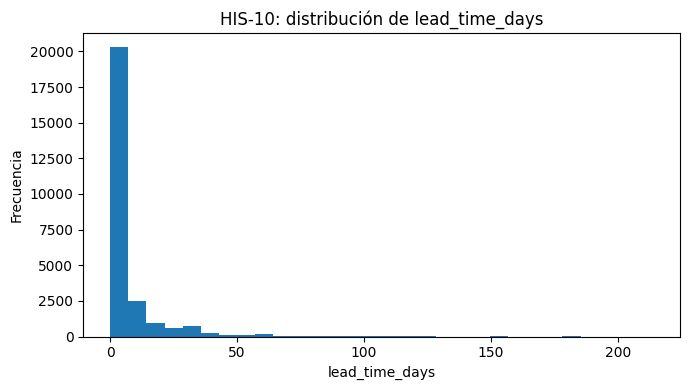

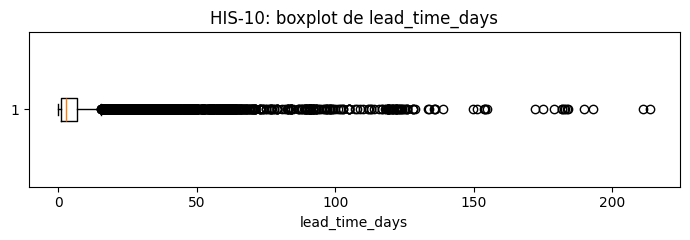

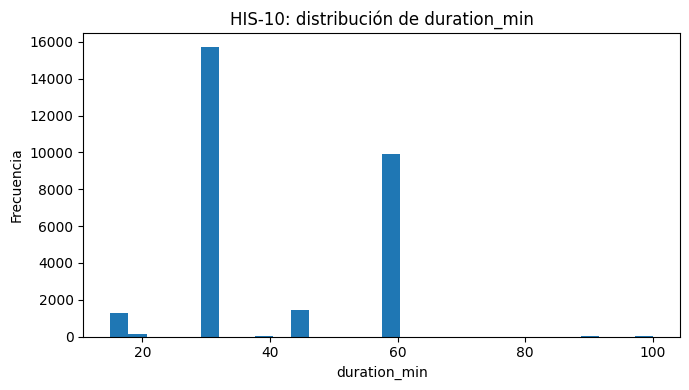

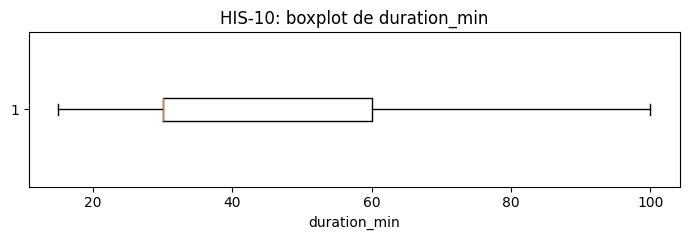

In [19]:
# Visualización de distribuciones de variables numéricas clave
# Se seleccionan variables numéricas relevantes de HIS-10.
#
# Para HIS-10 se revisan:
# - lead_time_days: anticipación de la cita.
# - duration_min: duración programada de la cita.
#
# Para cada variable se genera:
# - histograma: permite observar concentración, sesgo y dispersión.
# - boxplot: permite identificar mediana, rango intercuartílico y posibles outliers.

plot_cols = [
    ("HIS-10", preprocessed_data_his10, "lead_time_days"),
    ("HIS-10", preprocessed_data_his10, "duration_min"),
]

# Generación de histogramas y boxplots
# Se recorre cada variable seleccionada, se convierte a formato numérico
# y se eliminan valores faltantes únicamente para efectos de visualización.
# Los valores no se eliminan del dataset original.

for dataset_name, df, col in plot_cols:
    if col not in df.columns:
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    if s.empty:
        continue

    # Histograma: muestra la forma de la distribución.
    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=30)
    plt.title(f"{dataset_name}: distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Boxplot: muestra mediana, dispersión y posibles valores extremos.
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(s, vert=False)
    plt.title(f"{dataset_name}: boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Las gráficas muestran histogramas y boxplots de variables numéricas clave seleccionadas manualmente por su relevancia para los casos HIS-10. No se grafican todas las variables numéricas, sino aquellas que ayudan a revisar anticipación de citas, duración.

En **HIS-10**, `lead_time_days` presenta una distribución fuertemente sesgada a la derecha. La mayoría de las citas se agenda con pocos días de anticipación, pero existen casos con anticipaciones mucho mayores, incluso superiores a 100 o 200 días. El boxplot confirma una gran cantidad de valores extremos. Estos valores no necesariamente son errores, pero sí deben tratarse con cuidado en modelado, ya que pueden influir de forma desproporcionada.

La variable `duration_min` muestra una distribución más discreta y concentrada en duraciones estándar, principalmente alrededor de 30 y 60 minutos. El boxplot no muestra outliers importantes, lo cual sugiere que la duración de las citas tiene rangos razonables y más controlados.

En conjunto, las gráficas confirman que varias variables relevantes no siguen distribuciones normales y presentan sesgo positivo. Por ello, no conviene asumir normalidad ni eliminar valores extremos automáticamente. En cambio, deben documentarse y considerarse en decisiones posteriores de modelado.

##### Revisión de valores imposibles

Además de identificar outliers, se revisan reglas básicas para detectar valores imposibles o sospechosos en variables numéricas y temporales relevantes.

Estas reglas no necesariamente eliminan datos de forma automática, pero ayudan a identificar registros que deben tratarse con cuidado antes del modelado. En particular, se revisan condiciones como duraciones no plausibles, horas fuera de rango, tiempos negativos, edades fuera de rango, valores de espera demasiado altos y valores inválidos en el target.

Esta revisión es importante porque algunos valores extremos pueden ser casos reales, mientras que otros pueden deberse a errores de captura, fechas mal registradas o inconsistencias entre tablas.

Reglas consideradas:

- `duration_min <= 0`: duración de cita imposible.
- `appointment_hour < 0` o `appointment_hour > 23`: hora de cita fuera del rango válido.
- `lead_time_days < 0`: cita registrada después de la fecha programada.
- `m_edad_num < 0` o `m_edad_num > 120`: edad no plausible.
- `no_show` fuera de `{0, 1}`: valor inválido para un target binario.

In [20]:
# Revisión de valores imposibles o sospechosos
# Se construye una lista de validaciones para variables numéricas clave.
# Cada validación aplica una regla de negocio simple para detectar valores
# que no deberían ocurrir o que requieren revisión antes del modelado.

impossible_checks = []

# Función auxiliar para aplicar reglas de validación
# Esta función recibe:
# - nombre de la tabla,
# - dataframe,
# - columna a revisar,
# - condición lógica que define el valor imposible,
# - descripción de la regla.
#
# Después calcula cuántos registros incumplen la regla y qué porcentaje
# representan dentro de la tabla.

def add_impossible_check(table_name, df, column, condition, description):
    # Si la columna no existe en el dataframe, se omite la validación.
    if column not in df.columns:
        return

    # Se convierte la columna a numérica para poder aplicar comparaciones.
    # Los valores no convertibles se transforman en NaN.
    s = pd.to_numeric(df[column], errors="coerce")
    
    # Se aplica la condición definida para identificar valores imposibles.
    mask = condition(s).fillna(False)

    impossible_checks.append({
        "table": table_name,
        "column": column,
        "rule": description,
        "count": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
    })


# Reglas para HIS-10
# Se revisan variables numéricas relacionadas con citas médicas.
# Las reglas buscan detectar duraciones imposibles, horas fuera de rango,
# tiempos de anticipación negativos y edades no plausibles.

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "duration_min",
    lambda s: s <= 0,
    "duration_min <= 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "appointment_hour",
    lambda s: (s < 0) | (s > 23),
    "appointment_hour outside 0-23",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "lead_time_days",
    lambda s: s < 0,
    "lead_time_days < 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "m_edad_num",
    lambda s: (s < 0) | (s > 120),
    "m_edad_num outside 0-120",
)

# Validación del dominio del target HIS-10
# El target no_show debe ser binario:
# - 0: asistencia
# - 1: inasistencia / no-show
#
# Cualquier valor fuera de {0, 1} sería inválido para clasificación binaria.

if "no_show" in preprocessed_data_his10.columns:
    invalid_target = ~preprocessed_data_his10["no_show"].isin([0, 1])
    
    impossible_checks.append({
        "table": "preprocessed_data_his10",
        "column": "no_show",
        "rule": "no_show outside {0, 1}",
        "count": int(invalid_target.sum()),
        "pct": round(invalid_target.mean() * 100, 2),
    })

# Resumen de valores imposibles
# Se muestra una tabla con el resultado de todas las reglas aplicadas.

pd.DataFrame(impossible_checks)

,table,column,rule,count,pct
0,preprocessed_data_his10,duration_min,duration_min <= 0,0,0.0
1,preprocessed_data_his10,appointment_hour,appointment_hour outside 0-23,0,0.0
2,preprocessed_data_his10,lead_time_days,lead_time_days < 0,0,0.0
3,preprocessed_data_his10,m_edad_num,m_edad_num outside 0-120,0,0.0
4,preprocessed_data_his10,no_show,"no_show outside {0, 1}",0,0.0


La revisión de valores imposibles muestra resultados favorables para todas las reglas aplicadas.

En **HIS-10**, no se detectan duraciones de cita menores o iguales a cero, horas de cita fuera del rango válido `0–23`, edades fuera del rango ni valores negativos en `lead_time_days`. Esto indica que las variables principales de duración, horario y anticipación de cita tienen rangos lógicamente válidos. Además, el target `no_show` solo contiene valores dentro del dominio esperado `{0, 1}`, por lo que es válido para un problema de clasificación binaria.

En conjunto, estas reglas no muestran problemas graves de valores imposibles en las variables principales. Los principales puntos de atención siguen siendo la baja calidad de `m_edad_num`, los valores extremos previamente observados y las fechas fuera de rango detectadas en la validación temporal.

##### Variables categóricas

Se revisan las variables categóricas principales de los datasets finales para detectar valores raros, categorías dominantes, alta cardinalidad y posibles inconsistencias de codificación.

Este análisis es importante porque las variables categóricas pueden aportar información relevante al modelo, pero también pueden generar problemas si tienen demasiadas categorías, valores poco frecuentes, categorías mal escritas o una concentración excesiva en un solo valor.

En esta sección no se corrigen automáticamente todas las categorías; primero se documenta su distribución para decidir si conviene agrupar categorías raras, conservarlas, codificarlas como `UNKNOWN` o excluir variables con baja utilidad.

In [21]:
# Función auxiliar para perfilar variables categóricas
# Esta función muestra, para cada variable categórica seleccionada:
# - número de valores únicos,
# - categorías más frecuentes,
# - conteo de registros por categoría,
# - porcentaje que representa cada categoría dentro del dataset.

# Esto ayuda a detectar alta cardinalidad, categorías dominantes,
# valores raros o presencia excesiva de UNKNOWN.

def categorical_profile(df, cols, top_n=15):
    for col in cols:
        # Si la columna no existe en el dataframe, se omite.
        if col not in df.columns:
            continue

        # Se calculan las categorías más frecuentes.
        counts = (
            df[col]
            .value_counts(dropna=False)
            .head(top_n)
            .to_frame("count")
        )

        # Se agrega el porcentaje respecto al total de registros.
        counts["pct"] = (counts["count"] / len(df) * 100).round(2)

        print("=" * 80)
        print(col)
        print("unique values:", df[col].nunique(dropna=True))
        display(counts)

# Variables categóricas relevantes para HIS-10
# Se revisan variables provenientes de:
# - agenda médica: area, med, esp, tpo_cita;
# - campos operativos de la cita: conflicto, agregada, ultimahora, buffer;
# - episodio/atención: p_status, p_sexo;
# - paciente: m_sexo, m_cp, m_edo.
# Estas variables pueden aportar información para predecir no-show,
# pero también pueden presentar alta cardinalidad, categorías dominantes
# o muchos valores UNKNOWN.

his10_categorical = [
    "area",
    "med",
    "esp",
    "tpo_cita",
    "conflicto",
    "agregada",
    "ultimahora",
    "buffer",
    "p_status",
    "p_sexo",
    "m_sexo",
    "m_cp",
    "m_edo",
]

# Perfil categórico de HIS-10
# Se muestran las categorías más frecuentes de las variables seleccionadas.
# Esto permite identificar:
# - variables con pocos valores dominantes,
# - variables con muchos valores únicos,
# - variables con alta proporción de UNKNOWN,
# - posibles variables que requieran agrupación o tratamiento especial.

print("HIS-10 categorical variables")
categorical_profile(preprocessed_data_his10, his10_categorical)

HIS-10 categorical variables
area
unique values: 6


,count,pct
area,,
CZM,18146,63.56
PLY,8567,30.01
TUL,669,2.34
MAH,555,1.94
PTM,477,1.67
CUN,137,0.48


med
unique values: 126


,count,pct
med,,
703,1780,6.23
336,1360,4.76
000068,1281,4.49
605,1169,4.09
679,1068,3.74
001081,862,3.02
000985,821,2.88
1013,812,2.84
249,773,2.71


esp
unique values: 31


...

,count,pct
m_sexo,,
F,14251,49.91
M,11403,39.94
UNKNOWN,2891,10.13
N,6,0.02


m_cp
unique values: 72


,count,pct
m_cp,,
UNKNOWN,26684,93.46
77600,990,3.47
77645,153,0.54
77580,136,0.48
77667,124,0.43
77710,108,0.38
77660,41,0.14
77723,35,0.12
77760,35,0.12


m_edo
unique values: 37


,count,pct
m_edo,,
UNKNOWN,22385,78.4
23,3745,13.12
29,1068,3.74
31,621,2.18
06,131,0.46
21,116,0.41
24,65,0.23
16,61,0.21
20,58,0.2


En **HIS-10**, la variable `area` tiene 6 categorías, pero está concentrada principalmente en `CZM` y `PLY`, que juntas representan más del 93% de los registros. Esto indica que el dataset está dominado por esas dos áreas, por lo que el modelo podría aprender patrones principalmente de ellas y tener menos información para áreas con poca representación como `CUN`, `PTM`, `MAH` o `TUL`.

La variable `med` presenta 127 valores únicos, lo que indica alta cardinalidad. Esto puede aportar información relevante, ya que distintos médicos pueden tener diferentes patrones de agenda o asistencia, pero también requiere cuidado en el modelado para evitar sobreajuste o categorías con pocos registros.

La variable `esp` tiene 45 especialidades y una distribución más repartida. Las especialidades con mayor presencia son `MEDGEN`, `FISIOT`, `RADIOL`, `GINECO` y `ORTOPE`. Esta variable puede ser útil para el modelo, ya que la inasistencia podría variar dependiendo del tipo de servicio o especialidad.

La variable `tpo_cita` tiene dos categorías principales: `P` con 66.33% y `S` con 33.67%. Esta distribución es manejable y la variable parece aprovechable para modelado.

Las variables `conflicto`, `agregada` y `ultimahora` tienen una proporción extremadamente alta de `UNKNOWN`, superior al 99% en varios casos. Esto indica baja completitud o poca variabilidad, por lo que probablemente aporten poca información al modelo inicial. Podrían conservarse inicialmente, pero deben evaluarse con cuidado.

La variable `buffer` está dominada por `N`, con 99.29% de los registros. Aunque tiene pocos valores distintos, su baja variabilidad puede limitar su utilidad predictiva.

En `p_status`, se observan principalmente los códigos `00`, `50` y `02`. Esta variable podría aportar información, pero debe revisarse su significado operativo, ya que si representa un estado posterior a la cita podría generar fuga de información (*data leakage*).

Las variables de sexo (`p_sexo` y `m_sexo`) muestran principalmente valores `F` y `M`. En `m_sexo` aparece además un 10.13% de `UNKNOWN`, lo cual refleja que no todas las citas pudieron enriquecerse completamente con datos demográficos desde `HOSMPI`.

Las variables de ubicación, como `m_cp` y `m_edo`, tienen una proporción muy alta de `UNKNOWN`: 93.11% en código postal y 75.56% en estado. Esto limita su utilidad directa como variables predictoras. Además, aparecen valores como `00000`, `000` o `NA`, que podrían requerir homologación adicional como valores faltantes o no informativos.

En conjunto, esta revisión muestra que algunas variables categóricas son útiles y manejables, como `area`, `esp`, `tpo_cita`, `p_sexo` y `m_sexo`, mientras que otras presentan alta cardinalidad, baja variabilidad o demasiados valores `UNKNOWN`. Estas variables no necesariamente deben eliminarse en Data Engineering, pero sí deben revisarse en la etapa de modelado para decidir su codificación, agrupación o exclusión.

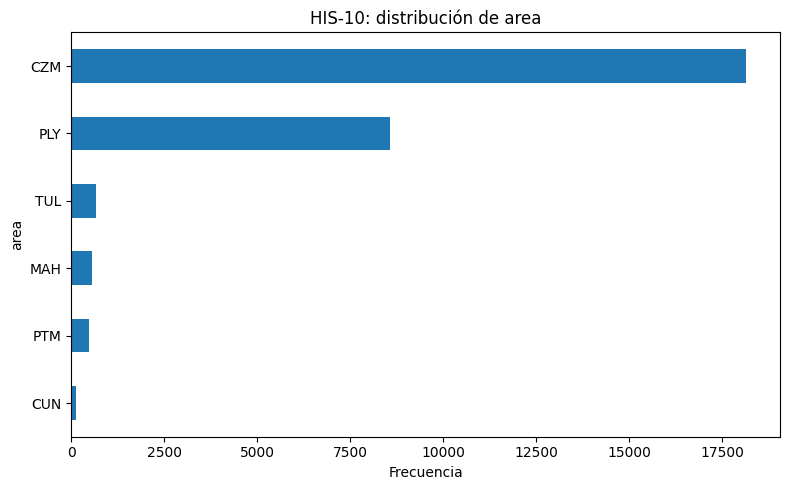

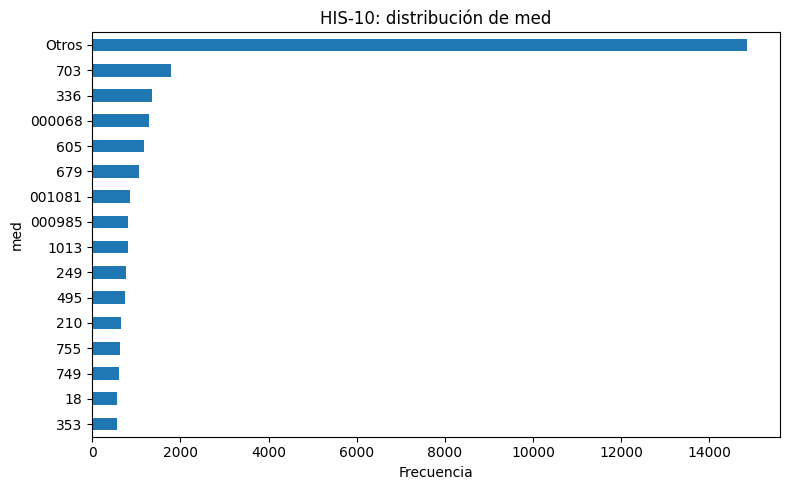

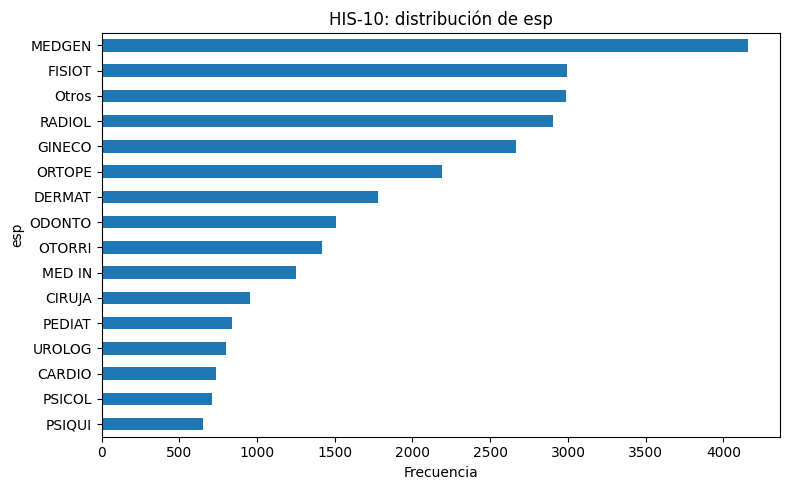

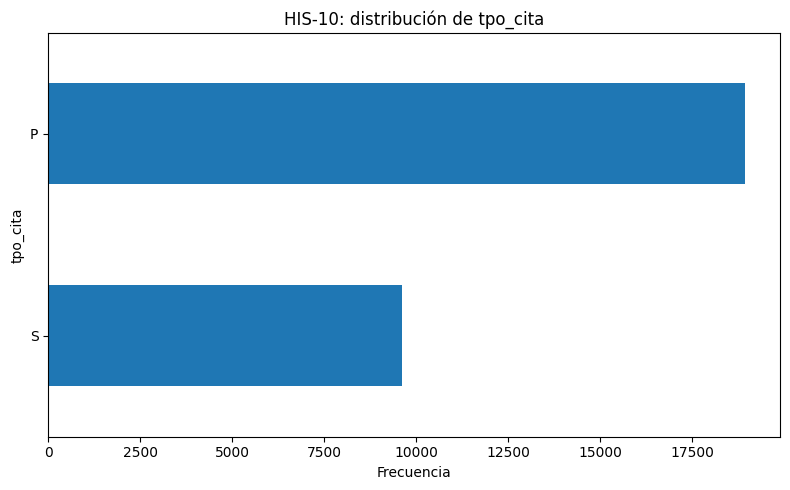

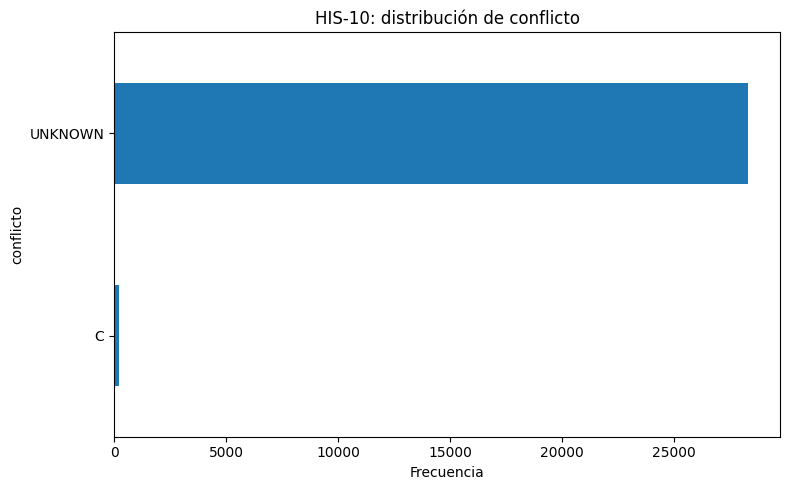

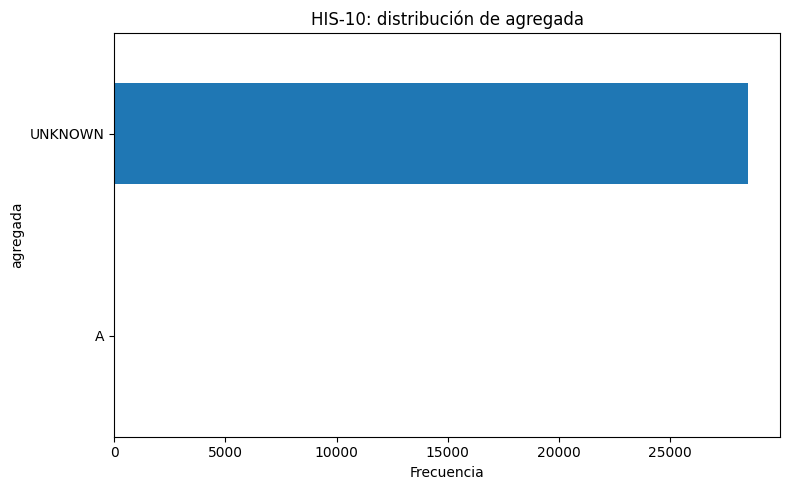

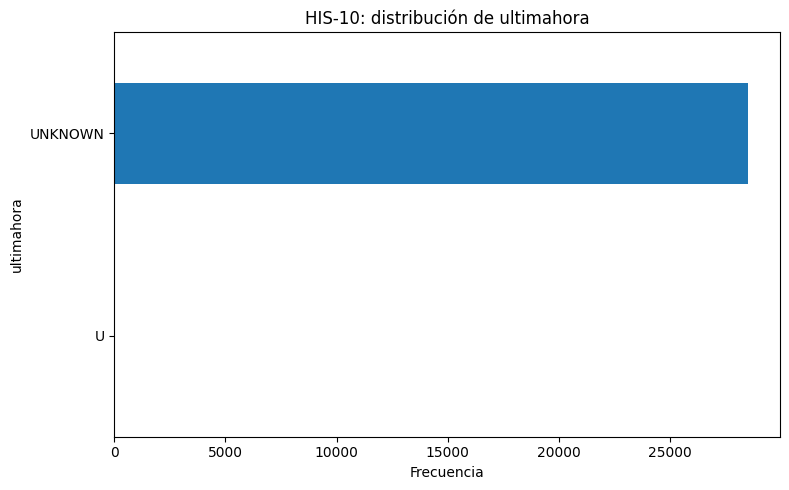

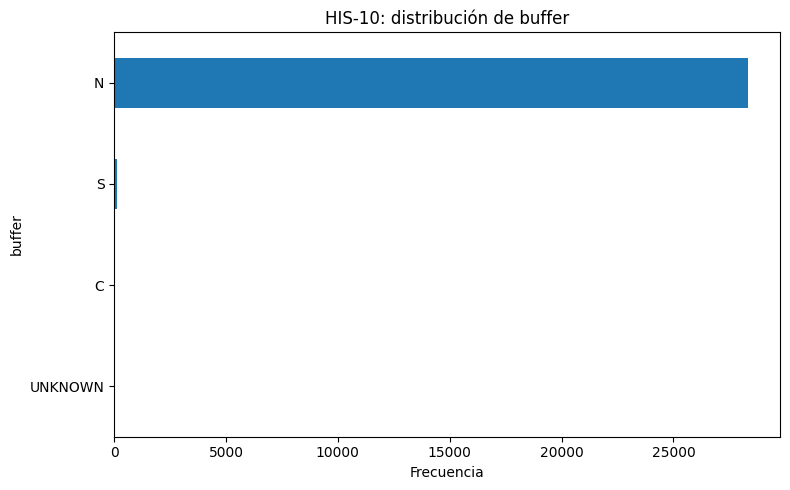

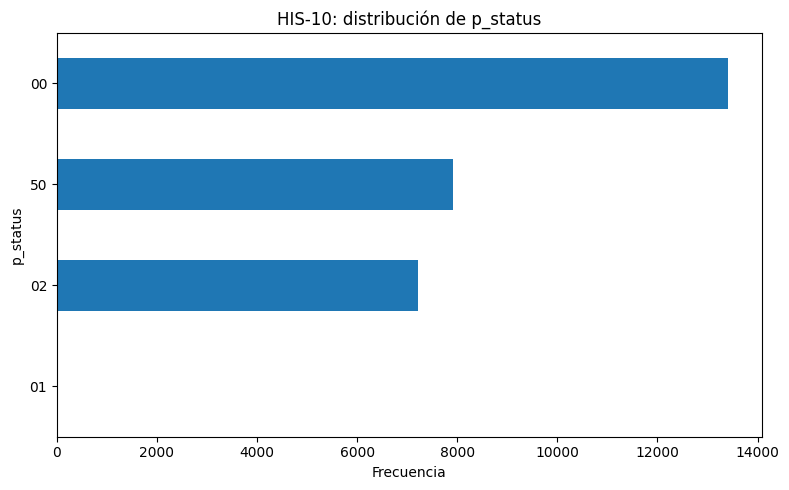

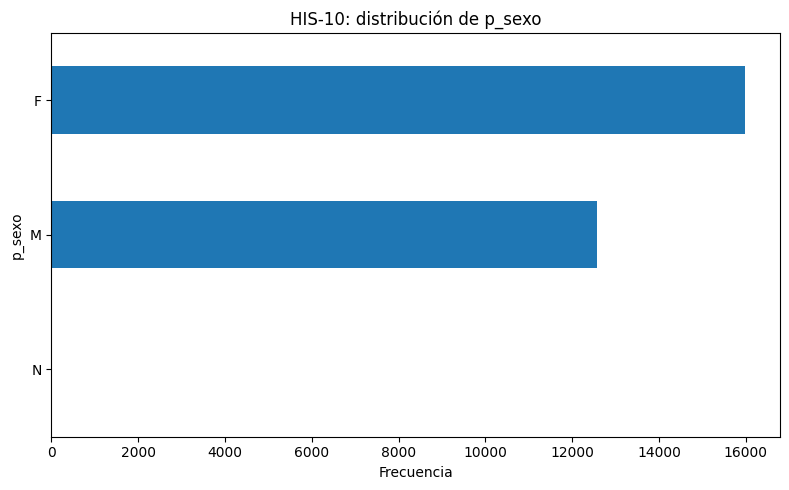

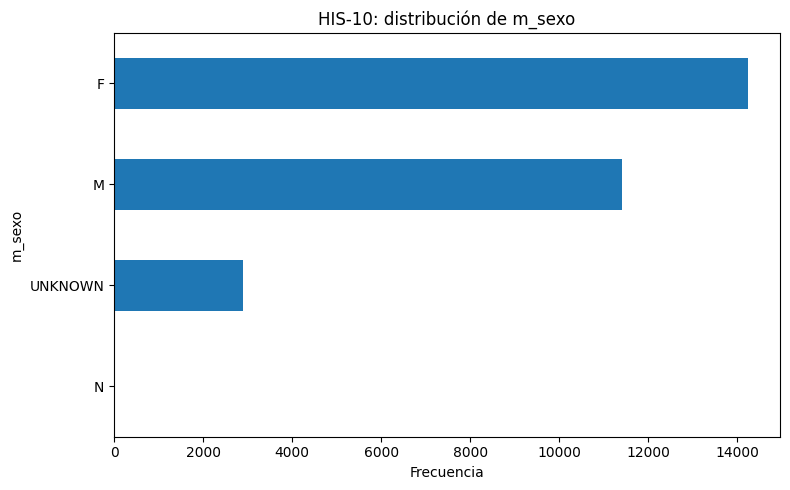

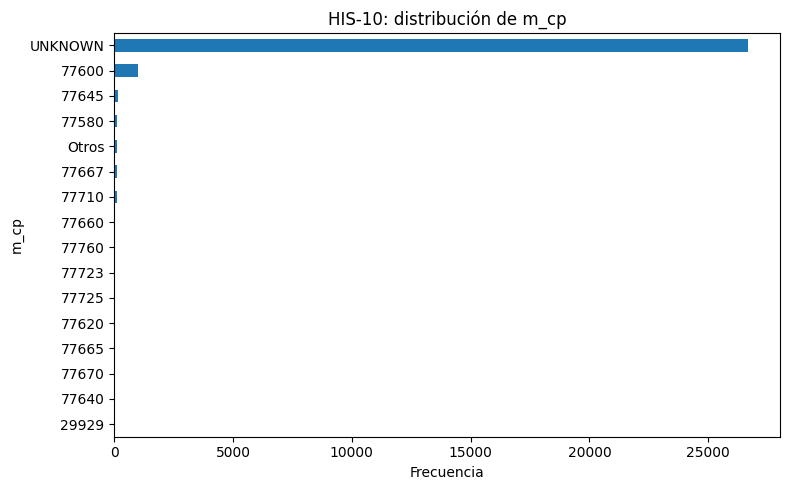

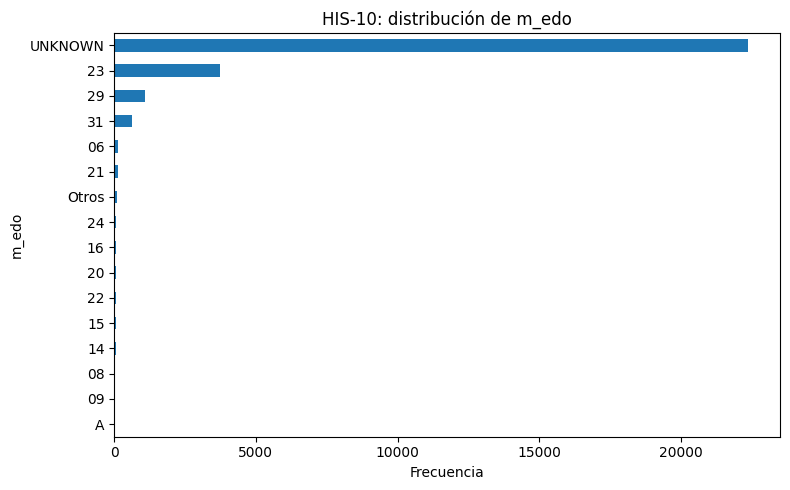

In [22]:
# Función auxiliar para graficar variables categóricas
# Esta función genera una gráfica de barras horizontales para una variable categórica.

# La gráfica muestra las categorías más frecuentes y, si existen más categorías
# que el límite definido por top_n, agrupa las restantes en una categoría llamada "Otros".

# Esto permite visualizar variables con muchas categorías sin saturar la gráfica.

def plot_categorical_counts(df, col, top_n=15, title_prefix=""):
    # Si la columna no existe en el dataframe, se omite la gráfica.
    if col not in df.columns:
        return

    # Se calculan las frecuencias de cada categoría.
    # dropna=False permite incluir valores faltantes si existieran.
    counts = df[col].value_counts(dropna=False)

    # Se conservan únicamente las categorías más frecuentes.
    counts_top = counts.head(top_n).copy()

    # Si hay más categorías fuera del top_n, se agrupan como "Otros".
    # Esto es útil para variables de alta cardinalidad como médico o código postal.
    if len(counts) > top_n:
        counts_top.loc["Otros"] = counts.iloc[top_n:].sum()

    # Se ordenan las barras de menor a mayor para mejorar la lectura visual.
    counts_top = counts_top.sort_values()

    # Se genera la gráfica de barras horizontales.
    plt.figure(figsize=(8, 5))
    counts_top.plot(kind="barh")
    plt.title(f"{title_prefix}: distribución de {col}")
    plt.xlabel("Frecuencia")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Selección de variables categóricas HIS-10
# Se seleccionan variables representativas del dataset final de HIS-10.
#
# Incluyen variables de:
# - agenda médica: area, med, esp, tpo_cita;
# - operación de la cita: conflicto, agregada, ultimahora, buffer;
# - episodio/atención: p_status, p_sexo;
# - paciente: m_sexo, m_cp, m_edo.
#
# La selección se enfoca en variables relevantes para revisar concentración,
# alta cardinalidad, valores UNKNOWN y posibles problemas de codificación.

his10_categorical_to_plot = [
    "area",
    "med",
    "esp",
    "tpo_cita",
    "conflicto",
    "agregada",
    "ultimahora",
    "buffer",
    "p_status",
    "p_sexo",
    "m_sexo",
    "m_cp",
    "m_edo",
]

# Gráficas de variables categóricas HIS-10
# Se genera una gráfica de barras para cada variable seleccionada.

# Para variables con muchas categorías, solo se muestran las 15 más frecuentes
# y el resto se agrupa en "Otros".

for col in his10_categorical_to_plot:
    plot_categorical_counts(
        df=preprocessed_data_his10,
        col=col,
        top_n=15,
        title_prefix="HIS-10"
    )

Las gráficas categóricas complementan el perfil anterior y permiten visualizar con mayor claridad la concentración de categorías.

En HIS-10, las gráficas confirman que `area` está dominada por `CZM` y `PLY`, mientras que variables como `med` y `esp` tienen mayor diversidad de categorías. También se observa que `conflicto`, `agregada` y `ultimahora` están dominadas por `UNKNOWN`, y que `buffer` está casi completamente concentrada en `N`.

Las variables demográficas y de ubicación muestran comportamientos distintos: `p_sexo` y `m_sexo` tienen una distribución relativamente interpretable entre `F` y `M`, aunque `m_sexo` conserva una proporción de `UNKNOWN`. En cambio, variables como `m_cp` y `m_edo` están muy dominadas por `UNKNOWN`, lo que limita su utilidad directa para modelado.

En conjunto, las visualizaciones refuerzan los hallazgos del perfil tabular: algunas variables categóricas son potencialmente útiles y manejables, mientras que otras presentan alta cardinalidad, baja variabilidad o demasiados valores `UNKNOWN`.

##### Revisión de tipos e inconsistencias categoricas
Se revisan variables categóricas para identificar posibles inconsistencias de escritura, espacios residuales, diferencias de mayúsculas/minúsculas, categorías raras, códigos sospechosos o valores que podrían representar faltantes de forma no estandarizada.

Esta revisión complementa el análisis de cardinalidad y frecuencias, ya que una variable puede tener una distribución aparentemente válida, pero aun así contener categorías mal codificadas o inconsistentes.

El objetivo no es corregir manualmente todas las categorías en el notebook, sino detectar posibles problemas que deban documentarse o tratarse posteriormente en el pipeline de limpieza o en la etapa de modelado.

In [23]:
# Revisión automática de inconsistencias textuales categóricas
# En esta celda se revisan posibles inconsistencias de escritura en variables
# categóricas, como:
# - espacios al inicio o final,
# - diferencias de mayúsculas/minúsculas,
# - acentos o marcas diacríticas,
# - valores codificados como UNKNOWN, NA, N/A o cadenas vacías.
#
# Esta revisión no valida si una categoría es correcta según su significado,
# sino si hay señales de escritura inconsistente o faltantes no informativos.

# Función auxiliar para normalizar texto
# Esta función convierte cualquier valor categórico a una versión comparable:
# - Si el valor es faltante, lo marca como "MISSING".
# - Convierte el valor a string.
# - Elimina espacios al inicio y al final.
# - Convierte a mayúsculas.
# - Elimina acentos.

def normalize_text_value(value):
    if pd.isna(value):
        return "MISSING"

    value = str(value).strip().upper()
    value = "".join(
        char for char in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(char)
    )
    return value

# Función auxiliar para revisar columnas categóricas
# Para cada columna seleccionada, se calcula:
# - raw_unique: número de categorías originales.
# - normalized_unique: número de categorías después de normalizar texto.
# - possible_text_inconsistency: indica si la normalización redujo categorías.
# - missing_or_unknown_count: conteo de valores faltantes o no informativos.
#
# Si normalized_unique < raw_unique, puede existir inconsistencia textual,
# por ejemplo la misma categoría escrita con espacios, acentos o mayúsculas distintas.

def categorical_typo_check(table_name, df, cols):
    rows = []

    for col in cols:
        # Si la columna no existe en la tabla, se omite.
        if col not in df.columns:
            continue

        # Se toma la versión original como texto.
        raw = df[col].astype("string")

        # Se crea una versión normalizada.
        normalized = raw.map(normalize_text_value)

        # Se cuentan valores faltantes o codificados como no informativos.
        missing_or_unknown_count = int(
            raw.isna().sum()
            + raw.str.strip().str.upper().isin(
                ["UNKNOWN", "MISSING", "NA", "N/A", ""]
            ).sum()
        )

        rows.append({
            "table": table_name,
            "column": col,
            "raw_unique": int(raw.nunique(dropna=True)),
            "normalized_unique": int(normalized.nunique(dropna=True)),
            "possible_text_inconsistency": int(
                normalized.nunique(dropna=True) < raw.nunique(dropna=True)
            ),
            "missing_or_unknown_count": missing_or_unknown_count,
        })

    return pd.DataFrame(rows)

# Aplicación de la revisión a variables categóricas seleccionadas
# Se revisan:

# 1. preprocessed_data_his10:
#    Variables categóricas finales de HIS-10.

# 2. processed_hosagd:
#    asistencia_clean, porque de esta variable se construye no_show.

# El objetivo es identificar columnas con posibles inconsistencias textuales
# o alta presencia de UNKNOWN / NA / faltantes.

categorical_typo_summary = pd.concat(
    [
        categorical_typo_check(
            "preprocessed_data_his10",
            preprocessed_data_his10,
            [
                "area",
                "med",
                "esp",
                "tpo_cita",
                "conflicto",
                "agregada",
                "ultimahora",
                "buffer",
                "p_status",
                "p_sexo",
                "m_sexo",
                "m_cp",
                "m_edo",
            ],
        ),
        categorical_typo_check(
            "processed_hosagd",
            processed_hosagd,
            ["asistencia_clean"],
        ),
    ],
    ignore_index=True,
)

# Ordenamiento del resumen

# Se ordenan primero las variables con posible inconsistencia textual,
# después las que tienen más valores faltantes/UNKNOWN,
# y finalmente las de mayor cardinalidad.
# Esto ayuda a priorizar qué variables revisar con más detalle.

categorical_typo_summary = categorical_typo_summary.sort_values(
    ["possible_text_inconsistency", "missing_or_unknown_count", "raw_unique"],
    ascending=False,
)

categorical_typo_summary

,table,column,raw_unique,normalized_unique,possible_text_inconsistency,missing_or_unknown_count
13,processed_hosagd,asistencia_clean,2,3,0,44467
5,preprocessed_data_his10,agregada,2,2,0,28520
6,preprocessed_data_his10,ultimahora,2,2,0,28520
4,preprocessed_data_his10,conflicto,2,2,0,28324
11,preprocessed_data_his10,m_cp,72,72,0,26684
12,preprocessed_data_his10,m_edo,37,37,0,22385
10,preprocessed_data_his10,m_sexo,4,4,0,2891
7,preprocessed_data_his10,buffer,4,4,0,30
1,preprocessed_data_his10,med,126,126,0,0
2,preprocessed_data_his10,esp,31,31,0,0


El resumen automático de inconsistencias categóricas muestra que la mayoría de las variables no presenta cambios entre el número de categorías crudas y normalizadas. Esto indica que, en general, no hay problemas fuertes por espacios, acentos o diferencias de mayúsculas/minúsculas en la mayoría de las columnas revisadas.

La principal posible inconsistencia textuales aparecen en `asistencia_clean`. Aquí, el número de categorías pasa de 2 a 3 después de normalizar, lo que sugiere que al menos dos códigos podrían diferir únicamente por formato textual.

También se observa que algunas variables tienen una gran cantidad de valores faltantes o codificados como `UNKNOWN`. En `asistencia_clean`, hay 44,467 valores faltantes, lo cual coincide con lo observado previamente: solo las citas con `A` o `I` se usan para construir el target de HIS-10. Las variables `agregada`, `ultimahora` y `conflicto` también tienen una cantidad muy alta de valores `UNKNOWN`, lo que confirma su baja completitud y posible baja utilidad directa para el modelo inicial.

Las variables demográficas y de ubicación, como `m_cp` y `m_edo`, también presentan muchos valores no informativos. En particular, `m_cp` tiene 26,684 valores faltantes o no informativos, y `m_edo` tiene 22,385. Esto refuerza que las variables de ubicación deben tratarse con cuidado antes de usarse como predictoras.

En conjunto, esta revisión confirma que el principal problema categórico no son errores masivos de escritura, sino variables con alta proporción de `UNKNOWN` o faltantes. Además, `asistencia_clean`, sí requiere atención porque la normalización aumenta el número de categorías, lo cual sugiere posibles duplicados semánticos por formato.

In [24]:
# Validación de dominios esperados en variables categóricas clave
# La revisión anterior detecta inconsistencias textuales, pero no necesariamente
# detecta valores inválidos según el significado de cada variable.
# Por ejemplo:
# - asistencia_clean debe ser A o I para construir el target.
# - no_show debe ser 0 o 1.

# Esta celda revisa dominios esperados para variables críticas.

expected_domains = {
    "asistencia_clean": {"A", "I"},
    "no_show": {0, 1},
    "tpo_cita": {"P", "S"},
    "p_sexo": {"F", "M", "N", "UNKNOWN"},
    "m_sexo": {"F", "M", "N", "UNKNOWN"},
}

# Fuentes donde se revisarán dominios
# Se revisan las tablas donde aparecen variables categóricas críticas:
#
# - processed_hosagd:
#   contiene asistencia_clean antes de construir la base final.
#
# - preprocessed_data_his10:
#   contiene variables categóricas finales y el target no_show.

domain_sources = [
    ("processed_hosagd", processed_hosagd),
    ("preprocessed_data_his10", preprocessed_data_his10),
]

# Aplicación de reglas de dominio
# Para cada variable con dominio esperado:
# - se ignoran valores faltantes,
# - se identifican valores explícitos fuera del dominio permitido,
# - se cuenta cuántos valores inválidos hay,
# - se guardan algunos ejemplos de valores inválidos.
# Esto permite detectar códigos raros aunque estén escritos de forma consistente.

domain_checks = []

for table_name, df in domain_sources:
    for col, valid_values in expected_domains.items():
        # Si la columna no existe en esa tabla, se omite.
        if col not in df.columns:
            continue

        values = df[col]

        # Se ignoran faltantes y se detectan valores explícitos inválidos.
        invalid_mask = values.notna() & ~values.isin(valid_values)

        domain_checks.append({
            "table": table_name,
            "column": col,
            "expected_domain": sorted(valid_values),
            "invalid_count": int(invalid_mask.sum()),
            "invalid_pct": round(invalid_mask.mean() * 100, 2),
            "invalid_examples": values[invalid_mask]
                .drop_duplicates()
                .head(10)
                .tolist(),
        })

# Resumen de validación de dominios
# Se muestra una tabla con:
# - tabla,
# - columna,
# - dominio esperado,
# - cantidad de valores inválidos,
# - porcentaje de valores inválidos,
# - ejemplos de valores inválidos.

domain_checks_df = pd.DataFrame(domain_checks)
domain_checks_df

,table,column,expected_domain,invalid_count,invalid_pct,invalid_examples
0,processed_hosagd,asistencia_clean,"[A, I]",0,0.0,[]
1,processed_hosagd,no_show,"[0, 1]",0,0.0,[]
2,processed_hosagd,tpo_cita,"[P, S]",0,0.0,[]
3,preprocessed_data_his10,no_show,"[0, 1]",0,0.0,[]
4,preprocessed_data_his10,tpo_cita,"[P, S]",0,0.0,[]
5,preprocessed_data_his10,p_sexo,"[F, M, N, UNKNOWN]",0,0.0,[]
6,preprocessed_data_his10,m_sexo,"[F, M, N, UNKNOWN]",0,0.0,[]


La validación de dominios esperados muestra que las variables categóricas críticas están, en general, dentro de los valores permitidos.

La variable `no_show` no presenta valores fuera del dominio `{0, 1}` ni en `processed_hosagd` ni en `preprocessed_data_his10`. Esto confirma que el target final quedó correctamente codificado como variable binaria para clasificación.

La variable `tpo_cita` tampoco presenta valores fuera del dominio esperado `{P, S}`, tanto en `processed_hosagd` como en `preprocessed_data_his10`. Esto indica que el tipo de cita quedó estandarizado y sin códigos inesperados en las bases revisadas.

Las variables de sexo (`p_sexo` y `m_sexo`) no presentan valores fuera del dominio definido `{F, M, N, UNKNOWN}`. Esto significa que los valores observados están dentro de los códigos permitidos, aunque `UNKNOWN` debe interpretarse como información faltante o no disponible.

En conjunto, esta validación muestra que no hay problemas relevantes de dominio en las variables categóricas críticas.

In [25]:
# Revisión manual de dominios categóricos seleccionados
# Además del resumen automático y la validación de dominios,
# se revisan manualmente algunas variables críticas.
#
# Esta revisión ayuda a inspeccionar valores raros específicos, por ejemplo:
# - caracteres no interpretables en asistencia_clean,
# - códigos poco frecuentes en sexo,
# - categorías de triage,
# - códigos postales no informativos como UNKNOWN, 00000, 000 o NA.

selected_categorical_domains = {
    "processed_hosagd.asistencia_clean": processed_hosagd["asistencia_clean"],
    "preprocessed_data_his10.p_sexo": preprocessed_data_his10["p_sexo"],
    "preprocessed_data_his10.m_sexo": preprocessed_data_his10["m_sexo"],
    "preprocessed_data_his10.m_cp": preprocessed_data_his10["m_cp"],
}

# Conteo de valores frecuentes por variable seleccionada
# Se muestran los 20 valores más frecuentes de cada variable,
# incluyendo faltantes, para facilitar la inspección manual.
# Esta celda complementa la validación automática porque permite ver
# directamente cuáles son los códigos o categorías que aparecen en los datos.

for name, series in selected_categorical_domains.items():
    print("=" * 80)
    print(name)

    display(
        series
        .value_counts(dropna=False)
        .head(20)
        .to_frame("count")
    )

processed_hosagd.asistencia_clean


,count
asistencia_clean,
<NA>,44467
A,21325
I,7226


preprocessed_data_his10.p_sexo


,count
p_sexo,
F,15989
M,12561
N,1


preprocessed_data_his10.m_sexo


,count
m_sexo,
F,14251
M,11403
UNKNOWN,2891
N,6


preprocessed_data_his10.m_cp


,count
m_cp,
UNKNOWN,26684
77600,990
77645,153
77580,136
77667,124
77710,108
77660,41
77723,35
77760,35


La revisión de tipos e inconsistencias categóricas se realizó sobre variables críticas de los datasets finales y de algunas tablas procesadas intermedias. Aunque idealmente esta revisión podría hacerse antes de la construcción final de los datasets, aquí se mantiene como una validación complementaria para documentar problemas que podrían afectar el modelado.

El resumen automático muestra que la mayoría de las variables categóricas no presenta diferencias importantes entre las categorías crudas y normalizadas, por lo que no hay evidencia de problemas generalizados por espacios, acentos o diferencias de mayúsculas/minúsculas mas que en `asistencia_clean`.

También se confirma que varias columnas tienen alta presencia de valores faltantes o no informativos. En particular, `asistencia_clean` tiene 44,467 valores faltantes; `agregada`, `ultimahora` y `conflicto` están dominadas por `UNKNOWN`; y variables de ubicación como `m_cp` y `m_edo` tienen muchos valores desconocidos o poco informativos. Esto refuerza que no todas las variables categóricas tienen la misma utilidad para modelado.

La validación de dominios esperados muestra resultados favorables en las variables críticas. El target `no_show` no presenta valores fuera de `{0, 1}`, tanto en la tabla procesada como en el dataset final de HIS-10. `tpo_cita`, `p_sexo`, `m_sexo` y `triage_clean`, `asistencia_clean` también se mantienen dentro de sus dominios esperados. 

La revisión manual confirma estos hallazgos. En `processed_hosagd.asistencia_clean`, los valores válidos son `A` e `I`, además de muchos faltantes. En `preprocessed_data_his10.p_sexo`, la variable está prácticamente concentrada en `F` y `M`, con un solo caso `N`. En `m_sexo`, también predominan `F` y `M`, aunque aparece una proporción relevante de `UNKNOWN`, lo que indica que no todas las citas pudieron enriquecerse con información demográfica desde `HOSMPI`.

En conjunto, la revisión muestra que no hay problemas graves de dominio en las variables categóricas principales. Los hallazgos más importantes son: alta presencia de `UNKNOWN` en variables operativas y de ubicación y códigos no informativos en `m_cp`. Estas observaciones no bloquean la construcción de los datasets finales, pero deben considerarse al decidir qué variables conservar, homologar, agrupar o excluir en la etapa de modelado.

##### Desbalance de clases para HIS-10
Para **HIS-10**, la variable objetivo es `no_show`, donde `0` representa asistencia y `1` representa inasistencia o No-Show.

Las citas con asistencia desconocida no se usan para el entrenamiento inicial, ya que imputar el resultado real de una cita podría sesgar el modelo.

En esta sección se revisa la distribución de clases para identificar si el target está balanceado. Esto es importante porque un desbalance fuerte puede hacer que el modelo favorezca la clase mayoritaria y que métricas como accuracy sean poco representativas.

In [26]:
# Conteo de clases del target HIS-10
# Se cuenta cuántas citas pertenecen a cada clase del target no_show.

# Codificación:
# - 0: el paciente asistió.
# - 1: el paciente no asistió / no-show.

target_counts = (
    preprocessed_data_his10["no_show"]
    .value_counts()
    .sort_index()
)

# Porcentaje de clases del target HIS-10
# Además del conteo absoluto, se calcula el porcentaje que representa
# cada clase dentro del dataset final de HIS-10.

# Esto permite evaluar si existe desbalance entre citas asistidas
# y citas no asistidas.

target_pct = (
    preprocessed_data_his10["no_show"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Construcción de tabla resumen del target
# Se integran conteos y porcentajes en una sola tabla para facilitar
# la interpretación del balance de clases.

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct.round(2),
})

# Etiquetado de clases
# Se renombran los índices para que la tabla sea más clara:
# - 0 = asistió.
# - 1 = no-show.

target_summary.index = ["0 = asistió", "1 = no-show"]

# Visualización del resumen
# Se muestra la distribución final del target de HIS-10.

target_summary

,count,pct
0 = asistió,21325,74.69
1 = no-show,7226,25.31


La distribución del target `no_show` muestra que el dataset final de HIS-10 tiene **21,325 citas asistidas** y **7,226 citas no asistidas**.

Esto equivale a:

- **74.69%** de citas con asistencia (`no_show = 0`).
- **25.31%** de citas con inasistencia o No-Show (`no_show = 1`).

Por lo tanto, existe un desbalance moderado entre las clases: la clase mayoritaria corresponde a citas asistidas. Sin embargo, la clase de No-Show todavía representa una proporción considerable del dataset, por lo que no es un caso extremo de desbalance. Además, cuadra con lo que se plantea en la definición del caso de uso, donde el porcentaje de ausentismo va del 15% al 25%.

Este resultado es importante para la etapa de modelado porque un modelo podría favorecer la clase mayoritaria si se evalúa únicamente con accuracy. Por ello, para HIS-10 conviene considerar métricas como precision, recall, F1-score y matriz de confusión, especialmente para evaluar qué tan bien se identifican los casos de No-Show.

### 2. Arquitectura del Pipeline y Selección de Modelos
Luego de concluir el análisis exploratorio y de calidad de los datos así como el procesamiento de estos para finalmente obtener la tabla `preprocessed_data_his10`, se plantea para esta etapa el diseño de una arquitectura donde se ponga a competir 3 modelos (Análisis Clásico de series de tiempo, Redes neuronales recurrentes y Transformers o mecanismos de atención) dado que en este esquema final ya no se observa un ID explícito del paciente para agrupar historiales secuenciales, por lo que el enfoque de los modelos se adapta para secuencias de agenda temporal y mecanismos de atención sobre características.

##### Análisis Clásico de Series de Tiempo
Cómo y Dónde: Se utilizará un modelo clásico como ARIMA sobre los datos agregados temporalmente. Se utilizarán las variables de tiempo como appointment_month, appointment_day, appointment_day_of_week para agrupar la tasa diaria de no_show.

Justificación: Esto nos permite modelar el comportamiento estacional macroscópico del hospital. ¿Hay más ausentismo los fines de semana (appointment_is_weekend) o a fin de mes? Este modelo dictará el riesgo base del día, sirviendo como comparativo frente a modelos más complejos.

##### Redes Neuronales Recurrentes
Cómo y Dónde: Se ordena la base de datos cronológicamente usando mes, día, hora y se agrupan las citas en ventanas de tiempo (ejemplo: las últimas 50 citas del día en una especialidad esp). La LSTM procesará la secuencia para predecir si la siguiente cita resultará en no_show = 1.

Justificación: En lugar de capturar el historial de un paciente, la LSTM capturará la dinámica operativa de la clínica. Si las últimas 5 citas de la mañana fueron no_show, tal vez haya un factor ambiental (clima, tráfico en m_ciu o m_col) que afecte a la siguiente cita. La LSTM detecta esta inercia a corto plazo.

##### Transformers (Mecanismo de Atención)
Cómo y Dónde: Se construye un Tabular Transformer donde el mecanismo de Self-Attention no se aplicará sobre el tiempo, sino sobre las características de cada cita. Variables como lead_time_days, esp y p_sexo se proyectarán como tokens.

Justificación: Existen dependencias cruzadas muy complejas y no lineales. Por ejemplo, el impacto del tiempo de espera (lead_time_days) sobre el riesgo de falta no es igual para una cita de cardiología que para medicina general, o para un paciente local ante un foráneo (m_edo). La atención cruzada extraerá estas dependencias globales multimodales ponderando qué combinación de variables es la causante del ausentismo.

#### Metodología y Descripción del Pipeline
El flujo de datos interactúa de la siguiente forma:

##### Capa de Preprocesamiento Final

Se separan las variables de preprocessed_data_his10 en numéricas (duration_min, lead_time_days, etc.) y categóricas (esp, med, tpo_cita, variables sociodemográficas m_*). Las numéricas se escalan y las categóricas se codifican (One-Hot Encoding). Se imputan nulos remanentes (ej. duration_min).

##### Capa de Agregación 

Para la serie de tiempo clásica, se genera un subset agrupando el promedio de no_show por día.

##### Capa Deep Learning Paralela

Para la LSTM, los datos procesados se agrupan en ventanas secuenciales de tensores 3D. Para el Transformer, el arreglo 2D procesado ingresa a bloques de atención densos que calculan pesos de importancia por feature para cada registro individual.

##### Capa de Salida 

Los modelos devuelven la probabilidad de que la variable `no_show` sea 1.

### 3. Implementación del preprocesamiento final con la arquitectura analítica

In [40]:
#Configuración inicial
#Se importan los frameworks necesarios para machine learning y deep learning
#Tensorflow, scikitlearn, statsmodels
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, LayerNormalization, MultiHeadAttention, Flatten, Reshape
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

#### Definición de esquema y preprocesamiento

In [28]:
# carga de preprocessed_data_his10
df = preprocessed_data_his10
df.head()

,area,med,esp,tpo_cita,conflicto,agregada,ultimahora,buffer,duration_min,appointment_hour,appointment_day_of_week,appointment_day,appointment_month,appointment_is_weekend,lead_time_days,lead_time_invalid,p_status,p_sexo,p_tpo_pac,p_tpo_cita,m_status,m_sexo,m_edad_num,m_ciu,m_col,m_cp,m_edo,m_pai,no_show
0,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,10,4,16,5,0,0.746389,0,02,F,TRI,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
1,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,19,5,0,1.777257,0,02,F,TRI,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
2,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,6,2,21,5,0,0.589456,0,02,M,TRI,P,10,M,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
3,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,2,21,5,0,0.650428,0,02,F,TRI,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
4,CZM,000002,ODONTO,S,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,26,5,0,1.836725,0,02,F,TRI,S,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1


In [29]:
# Variables según esquema
target = 'no_show'
num_cols = ['duration_min', 'appointment_hour', 'appointment_day_of_week', 
            'appointment_day', 'appointment_month', 'appointment_is_weekend', 
            'lead_time_days', 'lead_time_invalid'] 
#'m_edad_num' queda afuera por ahora porque solo tiene 1 valor que es muy extremo como para imputar tomando ese como referencia, se verá si tomar otra decisión para imputarla más adelante en el reto

cat_cols = ['area', 'med', 'esp', 'tpo_cita', 'conflicto', 'agregada', 'ultimahora', 
            'buffer', 'p_status', 'p_sexo', 'p_tpo_pac', 'p_tpo_cita', 
            'm_status', 'm_sexo', 'm_ciu', 'm_col', 'm_cp', 'm_edo', 'm_pai']

# Transformers de Scikit-Learn
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

#### Separación y transformación

In [30]:
#SEPARACIÓN Y TRANSFORMACIÓN
X = df.drop(['no_show', 'm_edad_num'], axis=1) # Elimina la columna objetivo y las no deseadas para dejar solo las X
y = df['no_show']

X_processed = preprocessor.fit_transform(X)
y_array = y.values

# Train/Test Split (respetando orden temporal si es posible)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_array, test_size=0.2, shuffle=False, random_state=42)

#### Análisis Clásico de Series de Tiempo

C:\Users\ivanl\AppData\Local\Temp\ipykernel_17524\1404613210.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_diaria.index, y=tasa_diaria.values, palette='viridis', ax=axes[1])


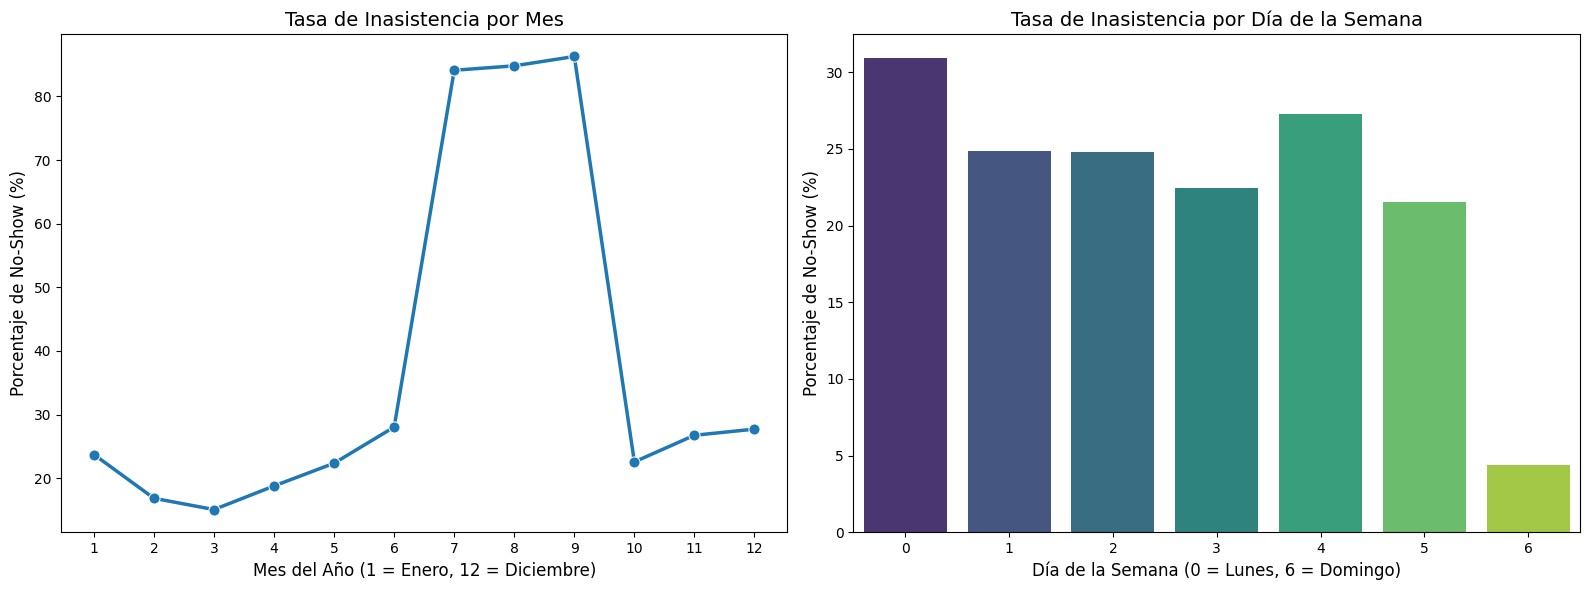

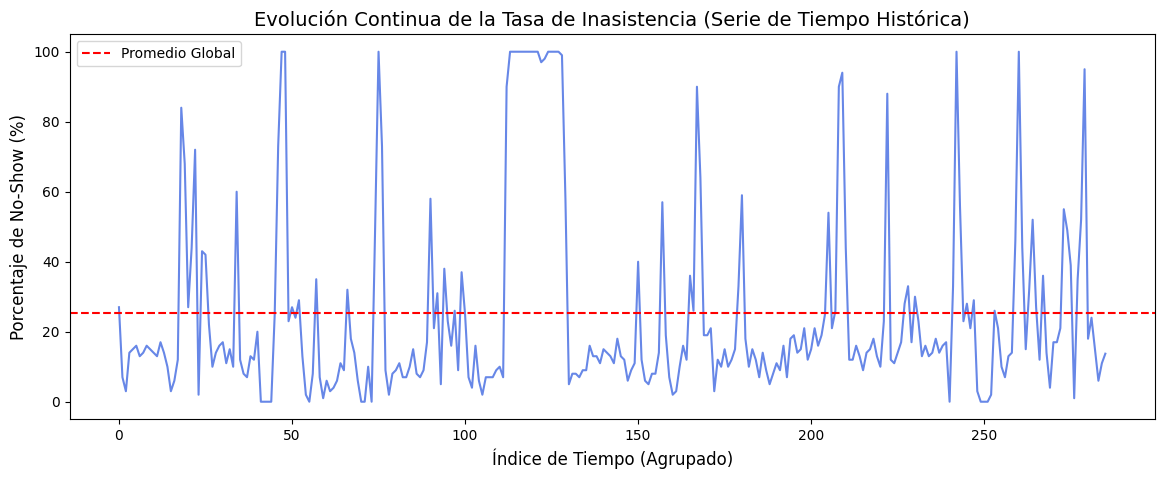

In [31]:
# Figura con dos subgráficos (uno para meses, otro para días de la semana)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. PICOS DE INASISTENCIA POR MES (Macro-estacionalidad)
# Calculamos el promedio de no_show por mes y lo multiplicamos por 100 para tener porcentaje
tasa_mensual = df.groupby('appointment_month')['no_show'].mean() * 100

sns.lineplot(x=tasa_mensual.index, y=tasa_mensual.values, 
             marker='o', linewidth=2.5, markersize=8, ax=axes[0])

axes[0].set_title('Tasa de Inasistencia por Mes', fontsize=14)
axes[0].set_xlabel('Mes del Año (1 = Enero, 12 = Diciembre)', fontsize=12)
axes[0].set_ylabel('Porcentaje de No-Show (%)', fontsize=12)
axes[0].set_xticks(range(1, 13)) # Asegurar que se vean todos los meses

# 2. PICOS DE INASISTENCIA POR DÍA DE LA SEMANA (Micro-estacionalidad)
# Calculamos el promedio por día de la semana
tasa_diaria = df.groupby('appointment_day_of_week')['no_show'].mean() * 100

# Usamos un gráfico de barras para los días
sns.barplot(x=tasa_diaria.index, y=tasa_diaria.values, palette='viridis', ax=axes[1])

axes[1].set_title('Tasa de Inasistencia por Día de la Semana', fontsize=14)
axes[1].set_xlabel('Día de la Semana (0 = Lunes, 6 = Domingo)', fontsize=12)
axes[1].set_ylabel('Porcentaje de No-Show (%)', fontsize=12)

plt.tight_layout()
plt.show()

# 3. SERIE DE TIEMPO 
# La serie continua "día tras día":
plt.figure(figsize=(14, 5))
# Agrupamos por bloques de citas para simular el paso del tiempo (si los datos están en orden temporal)
serie_continua = df['no_show'].groupby(df.index // 100).mean() * 100

plt.plot(serie_continua.index, serie_continua.values, color='royalblue', alpha=0.8)
plt.title('Evolución Continua de la Tasa de Inasistencia (Serie de Tiempo Histórica)', fontsize=14)
plt.xlabel('Índice de Tiempo (Agrupado)', fontsize=12)
plt.ylabel('Porcentaje de No-Show (%)', fontsize=12)
plt.axhline(y=df['no_show'].mean()*100, color='red', linestyle='--', label='Promedio Global')
plt.legend()
plt.show()


--- Entrenando ARIMA Baseline ---

--- Evaluación: ARIMA Baseline ---
AIC del Modelo ARIMA: -90.9904689766081


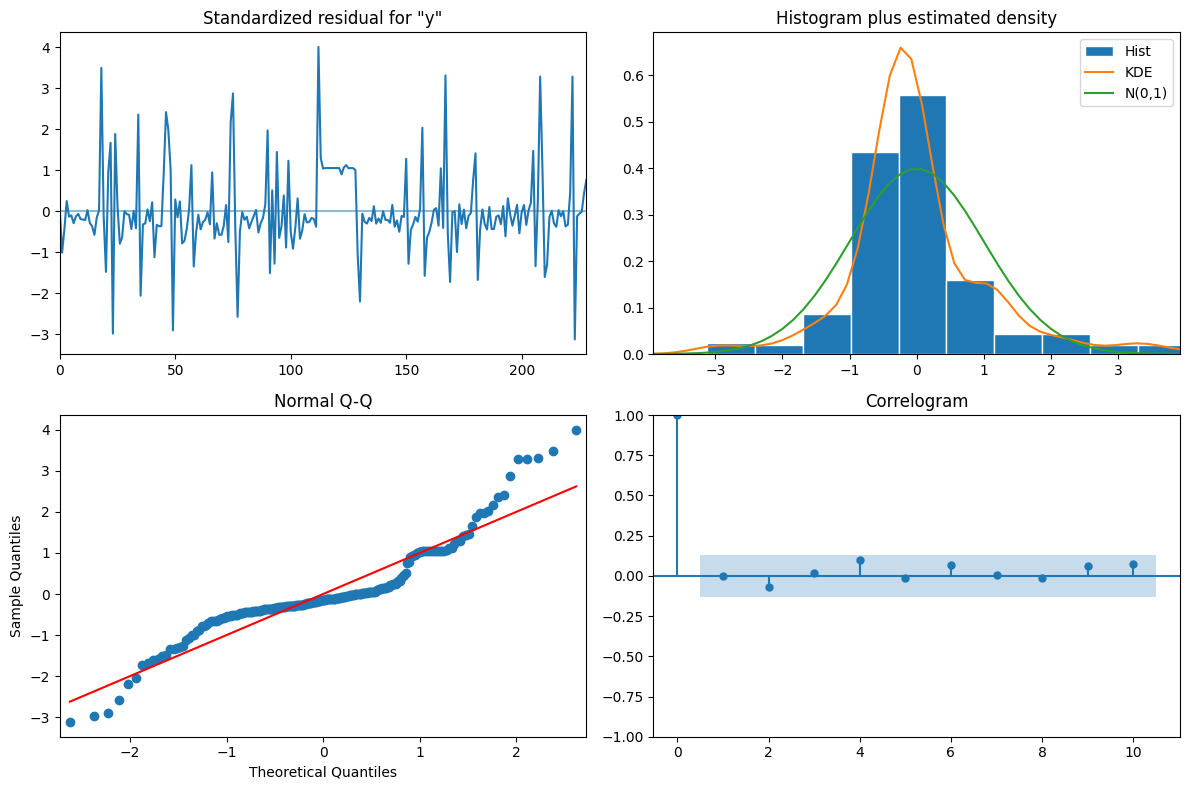

In [32]:
# Agrupamos por bloques de citas (simulando días)
y_train_series = pd.Series(y_train)
daily_rate = y_train_series.groupby(np.arange(len(y_train)) // 100).mean()

print("\n--- Entrenando ARIMA Baseline ---")
arima_model = ARIMA(daily_rate, order=(1, 0, 1)).fit()
print("\n--- Evaluación: ARIMA Baseline ---")
print("AIC del Modelo ARIMA:", arima_model.aic)
fig = arima_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

Dado que este modelo no puede clasificar a nivel registro de no_show individual, su utilidad queda relegada a entender picos de inasistencia, ya sea por meses o días de la semana. 

El valor AIC si bien es muy negativo lo cual es positivo para el modelo, tendría que ser comparado con otro para entender qué tan superior es. 

Además, el diágnostico de residuos muestra que el modelo ARIMA está bien ajustado, es estádisticamente válido y ha logrado capturar patrones temporales de los datos porque los residuos son puramente aleatorios.

#### Modelo RNN (LSTM)


--- Entrenando LSTM (Secuencia de Agenda) ---
Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8624 - loss: 0.3267 - val_AUC: 0.7478 - val_loss: 0.3915
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8828 - loss: 0.2931 - val_AUC: 0.7520 - val_loss: 0.4022
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8868 - loss: 0.2882 - val_AUC: 0.7480 - val_loss: 0.3931
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8906 - loss: 0.2838 - val_AUC: 0.7519 - val_loss: 0.3954
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8927 - loss: 0.2804 - val_AUC: 0.7521 - val_loss: 0.3973


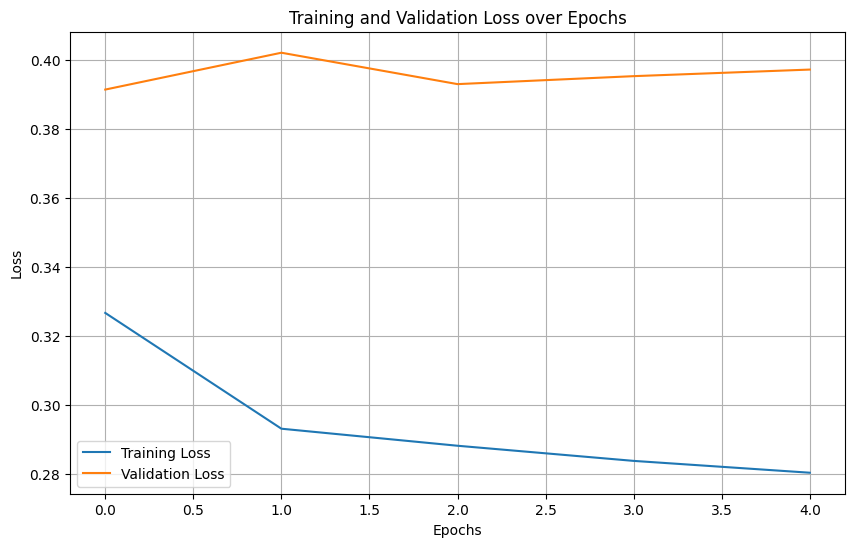

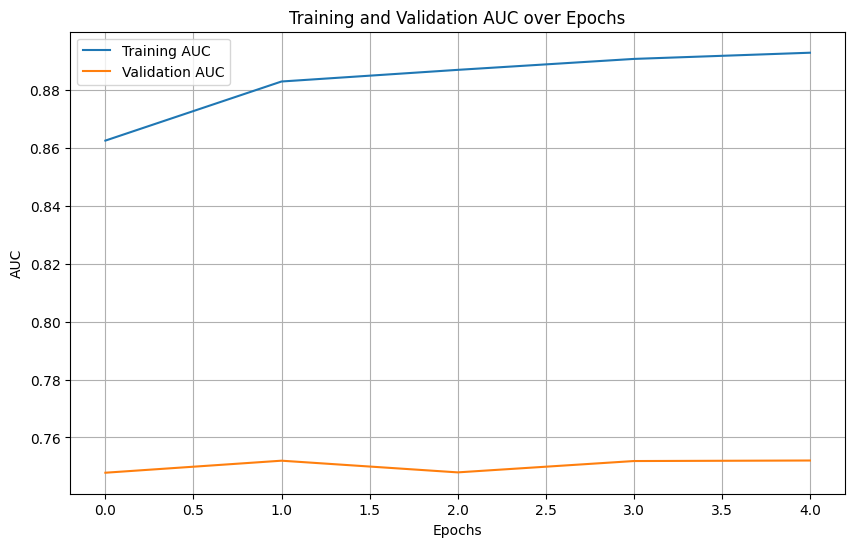

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluación: RNN LSTM ---
ROC-AUC: 0.8346
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4270
           1       0.57      0.65      0.61      1436

    accuracy                           0.79      5706
   macro avg       0.72      0.74      0.73      5706
weighted avg       0.80      0.79      0.79      5706



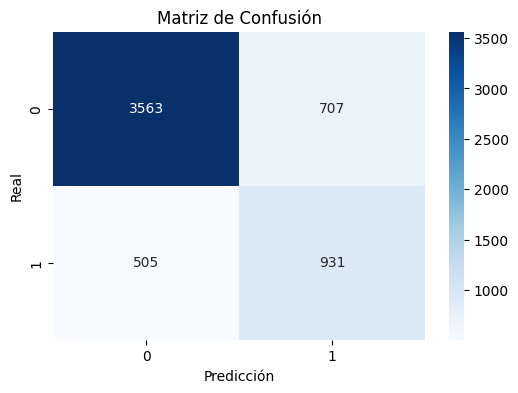

In [36]:
# PREPARACIÓN LSTM (Secuencias de Agenda)
# Agrupar los datos en ventanas móviles para simular la inercia del día
seq_length = 5
def create_sequences(data, labels, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:(i + seq_len)])
        ys.append(labels[i + seq_len])
    return np.array(xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length)

# Modelo LSTM (Entrenamiento)
inputs_lstm = Input(shape=(seq_length, X_processed.shape[1]))
x_l = LSTM(128)(inputs_lstm)
x_l = Dropout(0.2)(x_l)
x_l = LSTM(64)(inputs_lstm)
x_l = Dropout(0.2)(x_l)
x_l = Dense(32, activation='relu')(x_l)
out_lstm = Dense(1, activation='sigmoid')(x_l)

lstm_model = Model(inputs_lstm, out_lstm)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

print("\n--- Entrenando LSTM (Secuencia de Agenda) ---")
historylstm=lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

#grafico de loss (binary_crossentropy) para training y validation por epoch
plt.figure(figsize=(10,6))
plt.plot(historylstm.history['loss'], label='Training Loss')
plt.plot(historylstm.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

#grafico de AUC para training y validation por epoch
plt.figure(figsize=(10,6))
plt.plot(historylstm.history['AUC'], label='Training AUC')
plt.plot(historylstm.history['val_AUC'],label='Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC over Epochs')
plt.legend()
plt.grid()
plt.show()

#Predicciones, evaluación y outputs
pred_lstm = lstm_model.predict(X_test_seq).ravel()
# Ajuste de umbral por desbalance (25% no-show)
thresh = 0.25
class_lstm = (pred_lstm > thresh).astype(int)

print("\n--- Evaluación: RNN LSTM ---")
print(f"ROC-AUC: {roc_auc_score(y_test_seq, pred_lstm):.4f}")
print(classification_report(y_test_seq, class_lstm))
#Visualización
cm=confusion_matrix(y_test_seq, class_lstm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

El AUC con valor 0.83 resulta bueno pero al analizar el resto de métricas, se observa que la LSTM logra detectar rachas de inasistencias en el hospital basadas en el orden temporal de llegada, pero sufre de ruido en la validación porque la secuencia de citas agendadas a diferentes horas no es homogénea de paciente a paciente y esto se ve al final reflejado en que no es igual de bueno para predecir inasistencias que asistencias a las citas médicas (visto mediante recall).

#### Transformer (Mecanismo de Atención)


--- Entrenando Tabular Transformer ---
Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 89s 304ms/step - AUC: 0.9137 - loss: 0.5550 - val_AUC: 1.0000 - val_loss: 0.4571
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 87s 304ms/step - AUC: 0.9688 - loss: 0.2932 - val_AUC: 1.0000 - val_loss: 0.3662
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 87s 304ms/step - AUC: 0.9680 - loss: 0.2475 - val_AUC: 1.0000 - val_loss: 0.3003
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 86s 299ms/step - AUC: 0.9206 - loss: 0.2779 - val_AUC: 1.0000 - val_loss: 0.2616
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 89s 310ms/step - AUC: 0.9211 - loss: 0.2650 - val_AUC: 1.0000 - val_loss: 0.2301
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 88s 308ms/step - AUC: 0.9195 - loss: 0.2564 - val_AUC: 1.0000 - val_loss: 0.2046
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 88s 308ms/step - AUC: 0.8518 - loss: 0.3685 - val_AUC: 1.0000 - val_loss: 0.2105
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 89s 313ms/step - AUC: 0.7919 - loss: 0.4393 - val_AUC: 1.0000 - val_loss:

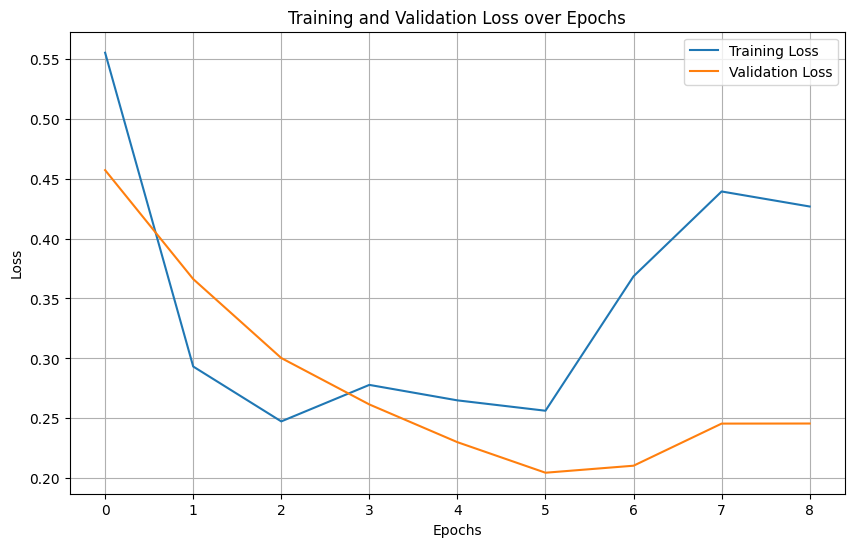

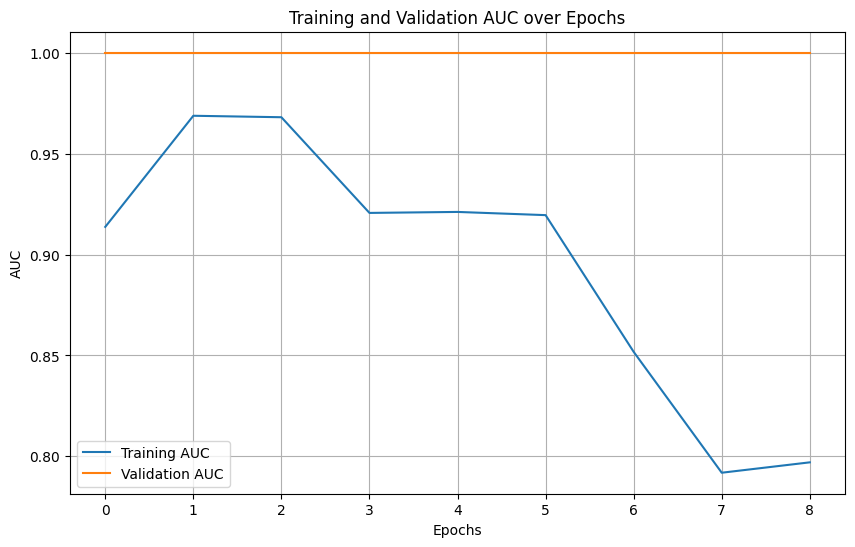

179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step

--- Evaluación: Tabular Transformer ---
ROC-AUC: 0.9996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4274
           1       1.00      1.00      1.00      1437

    accuracy                           1.00      5711
   macro avg       1.00      1.00      1.00      5711
weighted avg       1.00      1.00      1.00      5711



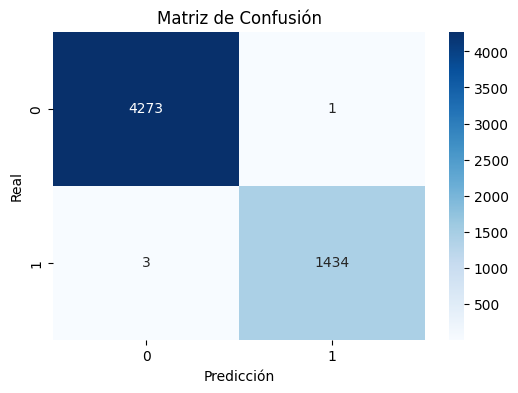

In [ ]:
#PREPARACIÓN TRANSFORMER (Tabular Attention)
# El transformer procesará cada registro de forma individual
inputs_tr = Input(shape=(X_train.shape[1],))

# Crear Embeddings de las características
# Expandir la dimensión
x_t = Reshape((X_train.shape[1], 1))(inputs_tr)
# Proyectar cada feature de 1 dimensión a 32 dimensiones
x_t = Dense(32, activation='relu')(x_t) 

# el Transformer tiene un espacio de 32 dimensiones para encontrar interacciones
attention = MultiHeadAttention(num_heads=2, key_dim=32)(x_t, x_t)
x_t = LayerNormalization(epsilon=0.000001)(attention + x_t) # Conexión residual
x_t = Flatten()(x_t)
x_t = Dense(64, activation='relu')(x_t)
x_t = Dropout(0.4)(x_t)
out_tr = Dense(1, activation='sigmoid')(x_t)

trans_model = Model(inputs_tr, out_tr)
trans_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# ARREGLO DEL DESBALANCE: Calcular pesos para forzar al modelo a prestar atención a ambas clases
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

early_stop = EarlyStopping(monitor='val_loss', 
                           patience=3, 
                           restore_best_weights=True, 
                           verbose=1)

print("\n--- Entrenando Tabular Transformer ---")
history_trans = trans_model.fit(X_train, y_train, 
                                epochs=10, 
                                batch_size=64, 
                                validation_split=0.2, 
                                verbose=1, 
                                class_weight=class_weights,
                                callbacks=[early_stop]) 

#grafico de loss (binary_crossentropy) para training y validation por epoch
plt.figure(figsize=(10,6))
plt.plot(history_trans.history['loss'], label='Training Loss')
plt.plot(history_trans.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

#grafico de AUC para training y validation por epoch
plt.figure(figsize=(10,6))
plt.plot(history_trans.history['AUC'], label='Training AUC')
plt.plot(history_trans.history['val_AUC'],label='Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC over Epochs')
plt.legend()
plt.grid()
plt.show()

# Predicciones, evaluación y outputs
pred_trans = trans_model.predict(X_test).ravel()

# con class_weights, las probabilidades ya están calibradas. 
# umbral estándar de 0.5
thresh = 0.50
class_trans = (pred_trans > thresh).astype(int)

print("\n--- Evaluación: Tabular Transformer ---")
print(f"ROC-AUC: {roc_auc_score(y_test, pred_trans):.4f}")
print(classification_report(y_test, class_trans))

# Visualización
cm = confusion_matrix(y_test, class_trans)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

El modelo de transformers con mecanismo de atención termina siendo el ganador con un AUC demasiado superior. Además, al observar el reporte de clasificación y la matriz de confusión, hay un aumento significativo en el Recall tanto para la clase 0 como para la clase 1 (No-Show). De hecho, la clasificación es casi perfecta y si bien se tendría que considerar el aplicar aún más técnicas para no incurrir en overfitting de las que ya se aplicaron, el Transformer logra esto porque su mecanismo de atención entiende reglas cruzadas que escapan a un modelo logístico. Por poner un ejemplo, es muy bueno en detectar que Si lead_time_days > 30 Y esp es Dermatología = Alto Riesgo de Ausentismo.

### Interpretación
El pipeline de modelos competitivos implementado sobre `preprocessed_data_his10` demuestra que no todas las técnicas avanzadas resuelven el problema de la misma manera. 

En primer lugar, lo resultante de ambos frente a un modelo de series de tiempo clásico muestra que el primero ni siquiera atiende la problématica de predecir mediante clasificación la inasistencia, pero sirve más para entender en qué temporalidad hay riesgo de inasistencia sin tomar mucho en cuenta el resto de factores, siempre y cuando esté bien ajustado y sea válido.

Pasando a la evaluación de desempeño de los otros modelos, el LSTM resulta poderoso para series puras, pero es subóptimo si no contamos con una secuencia clara del historial por paciente en los datos finales. Al usarla para predecir la inercia de la agenda, su poder predictivo es moderado pero no explota las variables sociodemográficas.

El Transformer en cambio justifica muy bien su implementación. Al tener tantas variables categóricas (m_ciu, m_col, esp, med) e indicadores como ultimahora o conflicto, el mecanismo de self-attention funciona como un extractor de relaciones causales. Aprende a qué variable prestarle atención dependiendo del contexto de la cita.

#### Impacto en Negocio 
En el contexto de HIS-10 (Optimizador de Agendas), un modelo basado en Transformers permite rankear cada cita con un score probabilístico de inasistencia de manera personalizada, dando luz verde operativa para implementar el sobreagendamiento inteligente de manera altamente segura y reduciendo los tiempos muertos del consultorio.